In [61]:
# Add directory above current directory to path
import sys as SYS; SYS.path.insert(0, '..'); SYS.path.insert(0, '../..')
import csv
import numpy as np
import pandas as pd
import random

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import networkx as nx
from scipy import stats
from scipy.stats import gaussian_kde, kurtosis, skew
from scipy.linalg import logm, expm

from src import density_matrix as DM
from src import circuit_architecture
from src import ket
from src import measurements as measure
from Scripts import simulation_CLI as cleo
from Scripts import hdf5merge

FIGURES_FILEPATH = './NM_figures/'

# Gate sequences

In [26]:
num_trials = 100
num_steps = 500
n_qubits = 8

num_trials_5gram = 99
num_steps_5gram = 400

## Gate probabilities for non-Markovian sequences

In [16]:
# Load gate probabilities dictionary
NM_gate_probs_all = np.load('../../non_markovian_orders_list/NM_gate_probabilities.npy',allow_pickle='TRUE').item()


for rule_name in NM_gate_probs_all.keys():
    mean_prob = np.mean(NM_gate_probs_all[rule_name][:,0])
    if 0.5-0.025 <= mean_prob <= 0.5+0.025:
        print(rule_name, mean_prob)

0_3_3_0 0.5167529880478088
1_1_3_2 0.4971115537848605
1_3_0_3 0.5040836653386453
2_0_2_3 0.499800796812749
2_2_1_3 0.5101195219123507
2_3_0_1 0.4836653386454182
g_g_j_j 0.5


## Dezhe's POMM sequences

In [17]:
# path to which I have stored Dezhe's generated sequences (for now)
saved_models_path = '../../non_markovian_orders_list/saved_models_from_Dezhe/'

ngram_5_dat_path = 'cPOMM_ngram_5_numSyms_2_kFanOut_6_POMM.dat' # trying to read .dat files
ngram_5_txt_path = 'cPOMM_ngramActual_5_numSyms_2_kFanOut_6_seqs.txt'

with open(saved_models_path + ngram_5_txt_path, 'r') as file:
    for line in file:
        reader = csv.reader(file)
        # store list of gate seq strings in variable named NM_list_{name}, i.e. NM_list_0_0_2_2
        NM_list_ngram_5 = [row[0].strip() for row in reader if row and row[0].strip()]
        NM_list_ngram_5 = [''.join(row.split(' ')).replace('0','j').replace('1','g') for row in NM_list_ngram_5]

len(NM_list_ngram_5)

99

## Load non-Markovian gates

In [18]:
# specify rules for which we want to check
NM_orders_names = ['0_0_2_2', '1_3_1_3', '1_3_0_3', '2_3_0_1', '2_0_2_3']

# open all the files for rules in NM_order_names
for name in NM_orders_names:
    with open(f'../../non_markovian_orders_list/rule_{name}.csv', 'r') as f:
        reader = csv.reader(f)
        # store list of gate seq strings in variable named NM_list_{name}, i.e. NM_list_0_0_2_2
        exec(f'NM_list_{name} = [row[0].strip() for row in reader if row and row[0].strip()]')

## Brickwork + deterministic n-gram

In [34]:
brick_patterns = ['jg','gj']
NM_list_brick = [''.join([brick_pattern for _ in range(0,int(num_steps/2 + 1))]) for brick_pattern in brick_patterns]
len(NM_list_brick[0])

502

In [20]:
# specify rules for which we want to check
NM_det_orders_names = ['g_j_j_j', 'g_g_j_j', 'g_g_g_j']

# open all the files for rules in NM_order_names
for name in NM_det_orders_names:
    with open(f'../../non_markovian_orders_list/rule_{name}.csv', 'r') as f:
        reader = csv.reader(f)
        # store list of gate seq strings in variable named NM_list_{name}, i.e. NM_list_0_0_2_2
        seqs = [row[0].strip() for row in reader if row and row[0].strip()]
        exec(f'NM_list_{name} = seqs')

# Run simulation

Note to self:

If large files ever present an issue to git push, refer to this [very helpful stack exchange post](https://stackoverflow.com/questions/25458306/git-rm-fatal-pathspec-did-not-match-any-files)

In [13]:
%%script echo skipping 
# comment the above line out to run this (computationally-expensive) cell

# random simulation

for unitary_seed in range(num_trials):
    #initial_pops = [0.043407, 0.12, 0.09, 0.15, 0.3,0.14, 0.23, 0.026593]
    #initial_pops = [1, 0, 0, 0, 1, 0, 0, 1]
    initial_pops = [0.1,0.1,0.1,0.1,0.4,0.1,0.1,0.1]
    system = DM.n_thermal_qbits(initial_pops)
    connectivity = "c2_2local"
    unitary_energy_subspace = 1
    ordering_seed = 1
    chunk_size = 2
    #random, mimic, greedy, landscape_maximizes, strongest_maximizes
    order_rule_name = "random"
    data = cleo.execute(file_name="random_trial",
                        connectivity=connectivity,
                        order_rule_name=order_rule_name,
                        unitary_seed=unitary_seed,
                        unitary_energy_subspace=unitary_energy_subspace,
                        evolution_generator_type="haar2Qunitary",
                        chunk_size=chunk_size,
                        num_steps=num_steps,
                        initial_pops=initial_pops,
                        channel_name="None",
                        channel_prob=0.0,
                        NM_orders_list = None,
                        verbosity=.9);

skipping


In [ ]:
%%script echo skipping
results, final_dm = data 
pops, _, _, _, _, _, _,_, random_orders_list = results

In [35]:
# %%script echo skipping 
# comment the above line out to run this (computationally-expensive) cell

# NM simulation

# TODO: , '2_0_2_3'

NM_order_list = NM_list_brick

for unitary_seed in range(2):
    #initial_pops = [0.043407, 0.12, 0.09, 0.15, 0.3,0.14, 0.23, 0.026593]
    #initial_pops = [0,0,0,0,1,0,0,0]
    NM_orders_list = NM_order_list[unitary_seed]
    initial_pops = [0.1,0.1,0.1,0.1,0.4,0.1,0.1,0.1]
    system = DM.n_thermal_qbits(initial_pops)
    connectivity = "c2_2local"
    unitary_energy_subspace = 1
    ordering_seed = 1
    chunk_size = 2
    order_rule_name = "NonMarkovian"
    num_steps = num_steps
    name_for_saving = f"{unitary_seed}"
    data = cleo.execute(file_name=f"Non_Markovian_Unitary_brick",
                        connectivity=connectivity,
                        order_rule_name = order_rule_name,
                        unitary_seed=unitary_seed,
                        unitary_energy_subspace=unitary_energy_subspace,
                        evolution_generator_type="haar2Qunitary",
                        chunk_size=chunk_size,
                        num_steps=num_steps,
                        initial_pops=initial_pops,
                        channel_name="None",
                        channel_prob=0.0,
                        NM_orders_list=NM_orders_list,
                        verbosity = .9);

g
[[0, 1], [2, 3], [4, 5], [6, 7]]
j
[[0, 7], [1, 2], [3, 4], [5, 6]]
g
[[0, 1], [2, 3], [4, 5], [6, 7]]
j
[[0, 7], [1, 2], [3, 4], [5, 6]]
g
[[0, 1], [2, 3], [4, 5], [6, 7]]
j
[[0, 7], [1, 2], [3, 4], [5, 6]]
g
[[0, 1], [2, 3], [4, 5], [6, 7]]
j
[[0, 7], [1, 2], [3, 4], [5, 6]]
g
[[0, 1], [2, 3], [4, 5], [6, 7]]
j
[[0, 7], [1, 2], [3, 4], [5, 6]]
g
[[0, 1], [2, 3], [4, 5], [6, 7]]
j
[[0, 7], [1, 2], [3, 4], [5, 6]]
g
[[0, 1], [2, 3], [4, 5], [6, 7]]
j
[[0, 7], [1, 2], [3, 4], [5, 6]]
g
[[0, 1], [2, 3], [4, 5], [6, 7]]
j
[[0, 7], [1, 2], [3, 4], [5, 6]]
g
[[0, 1], [2, 3], [4, 5], [6, 7]]
j
[[0, 7], [1, 2], [3, 4], [5, 6]]
g
[[0, 1], [2, 3], [4, 5], [6, 7]]
j
[[0, 7], [1, 2], [3, 4], [5, 6]]
g
[[0, 1], [2, 3], [4, 5], [6, 7]]
j
[[0, 7], [1, 2], [3, 4], [5, 6]]
g
[[0, 1], [2, 3], [4, 5], [6, 7]]
j
[[0, 7], [1, 2], [3, 4], [5, 6]]
g
[[0, 1], [2, 3], [4, 5], [6, 7]]
j
[[0, 7], [1, 2], [3, 4], [5, 6]]
g
[[0, 1], [2, 3], [4, 5], [6, 7]]
j
[[0, 7], [1, 2], [3, 4], [5, 6]]
g
[[0, 1], [2, 3], [

In [ ]:
# hdf5merge.merge_hdf5_files("../../data/Non_Markovian_Unitary_0_0_2_2")
# hdf5merge.merge_hdf5_files("../../data/Non_Markovian_Unitary_1_3_1_3")
# hdf5merge.merge_hdf5_files("../../data/Non_Markovian_Unitary_1_3_0_3")
# hdf5merge.merge_hdf5_files("../../data/Non_Markovian_Unitary_2_3_0_1")
# hdf5merge.merge_hdf5_files("../../data/Non_Markovian_Unitary_ngram_5")
# hdf5merge.merge_hdf5_files("../../data/random_trial")
# hdf5merge.merge_hdf5_files("../../data/Non_Markovian_Unitary_brick")
# hdf5merge.merge_hdf5_files("../../data/Non_Markovian_Unitary_g_j_j_j")
# hdf5merge.merge_hdf5_files("../../data/Non_Markovian_Unitary_g_g_j_j")
# hdf5merge.merge_hdf5_files("../../data/Non_Markovian_Unitary_g_g_g_j")

In [90]:
newdata_random = dict(h5py.File("../../data/random_trial/random_trial.hdf5"))
newdata_0_0_2_2 = dict(h5py.File("../../data/Non_Markovian_Unitary_0_0_2_2/Non_Markovian_Unitary_0_0_2_2.hdf5"))
newdata_1_3_1_3 = dict(h5py.File("../../data/Non_Markovian_Unitary_1_3_1_3/Non_Markovian_Unitary_1_3_1_3.hdf5"))
newdata_1_3_0_3 = dict(h5py.File("../../data/Non_Markovian_Unitary_1_3_0_3/Non_Markovian_Unitary_1_3_0_3.hdf5"))
newdata_2_3_0_1 = dict(h5py.File("../../data/Non_Markovian_Unitary_2_3_0_1/Non_Markovian_Unitary_2_3_0_1.hdf5"))
newdata_ngram_5 = dict(h5py.File("../../data/Non_Markovian_Unitary_ngram_5/Non_Markovian_Unitary_ngram_5.hdf5"))

newdata_all = {'random':newdata_random,
            '0_0_2_2' : newdata_0_0_2_2,
            '1_3_1_3' : newdata_1_3_1_3,
            '1_3_0_3' : newdata_1_3_0_3,
            '2_3_0_1' : newdata_2_3_0_1,
            'ngram_5' : newdata_ngram_5,
            }

In [91]:
newdata_g_j_j_j = dict(h5py.File("../../data/Non_Markovian_Unitary_g_j_j_j/Non_Markovian_Unitary_g_j_j_j.hdf5"))
newdata_g_g_j_j = dict(h5py.File("../../data/Non_Markovian_Unitary_g_g_j_j/Non_Markovian_Unitary_g_g_j_j.hdf5"))
newdata_g_g_g_j = dict(h5py.File("../../data/Non_Markovian_Unitary_g_g_g_j/Non_Markovian_Unitary_g_g_g_j.hdf5"))
newdata_brick = dict(h5py.File("../../data/Non_Markovian_Unitary_brick/Non_Markovian_Unitary_brick.hdf5"))

newdata_det = {
            'brick' : newdata_brick,
            'g_j_j_j':newdata_g_j_j_j,
            'g_g_j_j':newdata_g_g_j_j,
            'g_g_g_j':newdata_g_g_g_j}

# Circuit architecture

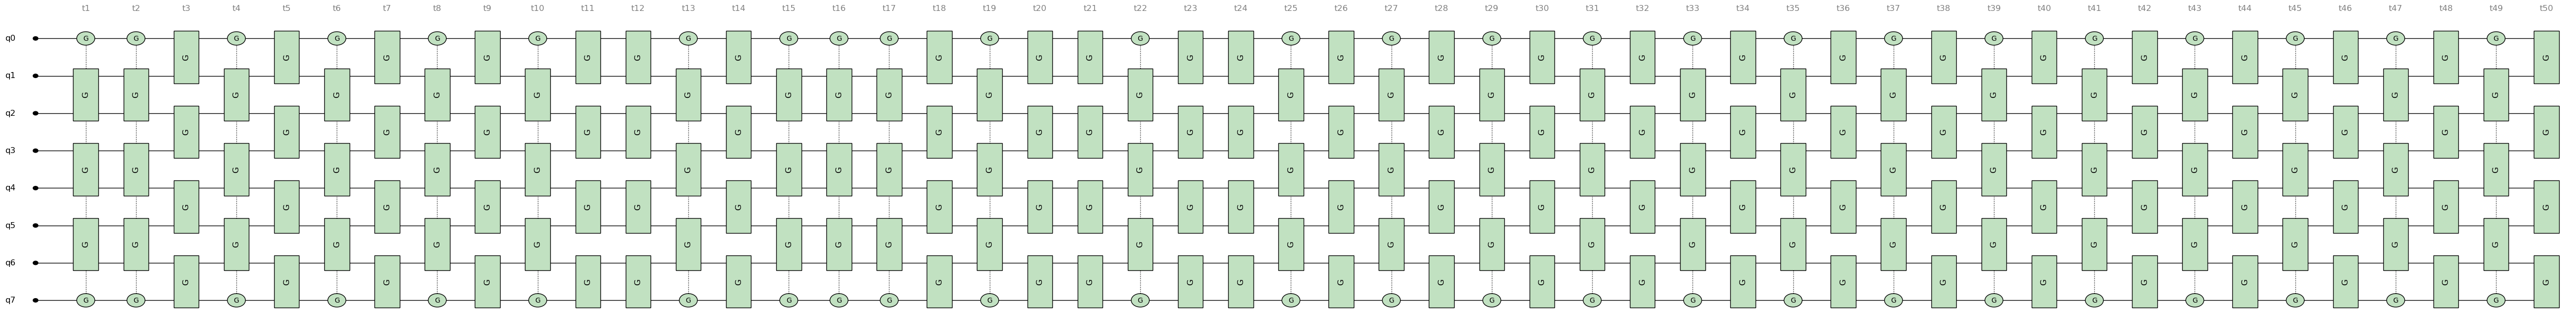

In [53]:
n_qubits=8
trial_index=1

# TODO: output random rule gate seqs to plot here

gate_seq = circuit_architecture.generate_gate_sequence_from_NM_pattern(NM_list_1_3_0_3[trial_index],n_qubits)
circuit_architecture.draw_quantum_circuit(n_qubits, 50, gate_seq, 
                                        circuitname=FIGURES_FILEPATH + 'circuit_arch_brick.png')


# Get_pops

In [92]:
def get_pops(data, n_qubits, connectivity,update_rule):
    #dimension 0 is each trial
    #dimension 1 is each time step
    #dimension 2 is each qubit
    result = []
    for trial in data[f'{n_qubits} qubits'][f'{connectivity} connectivity']['unitary energy subspace 1']:
        seed = trial.split(' ')[-1]
        dat = dict(data[f'{n_qubits} qubits'][f'{connectivity} connectivity']['unitary energy subspace 1'][f'unitary seed {seed}'][f'ordering seed {update_rule}']['pops'])
        dat = {int(k.split('(')[0]): dat[k] for k in dat}
        dat = np.array([np.array([dat[k][subkey][()] for subkey in sorted(dat[k])]) for k in sorted(dat)])
        result.append(dat)
    return(np.array(result))

In [93]:
# compute populations for all probabilistic rules 
pops_NM_all = {}
for rule_name in newdata_all:
    if rule_name == 'random': 
        pops_NM_all[rule_name] = get_pops(newdata_all[rule_name], n_qubits, "c2_2local", "random")
    else:
        pops_NM_all[rule_name] = get_pops(newdata_all[rule_name], n_qubits, "c2_2local", "NonMarkovian")

In [94]:
# compute populations for all deterministic rules
pops_NM_det = {}
for rule_name in newdata_det:
    pops_NM_det[rule_name] = get_pops(newdata_det[rule_name], n_qubits, "c2_2local", "NonMarkovian")

# Node evolution

In [180]:
def plot_node_evolution_single_trial(pops_data, trial_num, steps_range = None, rule_name='',convert_to_z = False):
    ''' 
    Plot the node evolution as both line graph and heatmap. 

    Paramters
    ---------
    - pops_data : array,
        pops data corresponding to one single trial, of dim (# steps, # qubits).
    - trial_num : int,
        # of trial to plot 
    - steps_range : tuple(int),
        range of steps to trim the data for. 
    - rule_name : str,
        rule_name to save the figures.
    - convert_to_z : bool,
        whether to convert pops data (p) into coefficient a_z for σ_z
        a_z = 1 - 2 p
    '''
    
    pops_data = np.asarray(pops_data[trial_num,:,:])
    if convert_to_z:
        data = -2.0 * pops_data + 1.0
    else:
        data = pops_data
    
    # if steps_range are not given, assume we're plotting entire evolution
    if not steps_range:
        time_steps, num_nodes = data.shape
        steps_range = (0, time_steps)
    else: 
        data = data[steps_range[0]:steps_range[1]]
        time_steps, num_nodes = data.shape

    # Line plot: evolution of each node
    plt.figure(figsize=(10, 6))
    for i in range(num_nodes):
        plt.plot(range(steps_range[0],steps_range[1]), data[:, i], label=f'Node {i}')
    plt.xlabel('Time step')
    if convert_to_z:
        plt.ylabel(r'$z_q$')
    else:
        plt.ylabel(r'$p_q$')
    plt.xlim(steps_range[0],steps_range[1]-1)
    plt.title(f'Rule {rule_name} trial {trial_num} node evolution')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{FIGURES_FILEPATH}node_evol_{rule_name}_trial_{trial_num}.png',dpi=300, bbox_inches='tight')
    plt.show()

    # Heatmap: time vs node
    plt.figure(figsize=(3, 6))
    plt.imshow(data, aspect='auto', cmap='viridis', origin='lower')
    if convert_to_z:
        plt.colorbar(label=r'$z_q$')
    else:
        plt.colorbar(label=r'$p_q$')
    plt.xlabel('Node')
    plt.ylabel('Time step')
    plt.title(f'Rule {rule_name} trial {trial_num} \n steps {steps_range[0]}-{steps_range[1]} node evol.',
            fontsize=10)
    plt.tight_layout()

    plt.savefig(f'{FIGURES_FILEPATH}node_evol_heatmap_{rule_name}_trial_{trial_num}.png',dpi=300, bbox_inches='tight')
    plt.show()

def plot_node_evolution_trial_avg(pops_data, steps_range = None, rule_name='',convert_to_z = False):
    ''' 
    Plot the node evolution as both line graph and heatmap. 

    Paramters
    ---------
    - pops_data : array,
        pops data corresponding to many trials, of dim (# trials, # steps, # qubits).
    - steps_range : tuple(int),
        range of steps to trim the data for. 
    - title : str,
        title to save the figures.
    - convert_to_z : bool,
        whether to convert pops data (p) into coefficient a_z for σ_z
        a_z = 1 - 2 p
    '''
    # take average over all trials (dimension 0) of pops_data 
    pops_data = np.mean(pops_data, axis=0)

    pops_data = np.asarray(pops_data)
    if convert_to_z: # convert p to z
        data = -2.0 * pops_data + 1.0
    else:
        data = pops_data

    # if steps_range are not given, assume we're plotting entire evolution
    if not steps_range:
        time_steps, num_nodes = data.shape
        steps_range = (0, time_steps)
    else: 
        data = data[steps_range[0]:steps_range[1]]
        time_steps, num_nodes = data.shape

    # Line plot: evolution of each node
    plt.figure(figsize=(10, 6))
    for i in range(num_nodes):
        plt.plot(range(steps_range[0],steps_range[1]), data[:, i], label=f'Node {i}')
    plt.xlabel('Time step')
    if convert_to_z:
        plt.ylabel(r'$\langle z_q \rangle$')
    else:
        plt.ylabel(r'$\langle p_q \rangle$')
    plt.xlim(steps_range[0],steps_range[1]-1)
    plt.title(f'Node Evolution Over Time for Rule {rule_name}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_FILEPATH + 'node_evol_' + rule_name + '.png',dpi=300, bbox_inches='tight')
    plt.show()

    # Heatmap: time vs node
    plt.figure(figsize=(3,6))
    plt.imshow(data, aspect='auto', cmap='viridis', origin='lower')
    if convert_to_z:
        plt.colorbar(label=r'$\langle z_q \rangle$')
    else:
        plt.colorbar(label=r'$\langle p_q \rangle$')
    plt.xlabel('Node')
    plt.ylabel('Time step')
    plt.title(f'Rule {rule_name} all trial avg. \n steps {steps_range[0]}-{steps_range[1]} node evol.',
            fontsize=10)
    plt.tight_layout()

    plt.savefig(FIGURES_FILEPATH + 'node_evol_heatmap_' + rule_name + '.png',dpi=300, bbox_inches='tight')
    plt.show()


In [181]:
def plot_node_evolution_trial_avg(pops_data, ax, 
                                steps_range = None, 
                                rule_name='',
                                convert_to_z = False, 
                                style='heatmap',
                                label_ax = False):
    ''' 
    Plot the node evolution as a line graph and heatmap. 

    Paramters
    ---------
    - pops_data : array,
        pops data corresponding to many trials, of dim (# trials, # steps, # qubits).
    - ax : matplotlib axis,
        axis on which to plot
    - steps_range : tuple(int),
        range of steps to trim the data for. 
    - title : str,
        title to save the figures.
    - convert_to_z : bool,
        whether to convert pops data (p) into coefficient a_z for σ_z
        a_z = 1 - 2 p
    - style : str,
        either 'line' or 'heatmap'.
    - label_ax : bool,
        whether to label axis with legend/colorbar
    '''
    # take average over all trials (dimension 0) of pops_data 
    pops_data = np.mean(pops_data, axis=0)

    pops_data = np.asarray(pops_data)
    if convert_to_z: # convert p to z
        data = -2.0 * pops_data + 1.0
    else:
        data = pops_data

    # if steps_range are not given, assume we're plotting entire evolution
    if not steps_range:
        time_steps, num_nodes = data.shape
        steps_range = (0, time_steps)
    else: 
        data = data[steps_range[0]:steps_range[1]]
        time_steps, num_nodes = data.shape

    # Line plot: evolution of each node
    if style == 'line': 
        for i in range(num_nodes):
            ax.plot(range(steps_range[0],steps_range[1]), data[:, i], label=f'Node {i}')
        ax.set_xlim(steps_range[0],steps_range[1]-1)
        if label_ax:
            ax.set_xlabel('Time step')
            ax.legend()
            if convert_to_z:
                ax.set_ylabel(r'$\langle z_q \rangle$')
            else:
                ax.set_ylabel(r'$\langle p_q \rangle$')
        ax.set_title(f'Rule {rule_name}')

    # Heatmap: time vs node
    if style == 'heatmap':
        im = ax.imshow(data, aspect='auto', cmap='Spectral', origin='lower')
        ax.set_xlabel('Node')
        ax.set_xticks([i for i in range(num_nodes)])
        ax.set_title(rule_name,
                fontsize=10)
        return im 
    

def plot_all_node_evol_heatmaps(pops, steps_range = (0,400), convert_to_z = True):
    '''
    Plot multiple node evolution heatmaps together using plot_node_evolution_trial_avg().
    '''
    rule_names = pops.keys()

    fig, axs = plt.subplots(1, len(rule_names), figsize=(1*len(rule_names),6),
                            sharex=True,sharey=True)

    images = []
    for i,rule_name in enumerate(rule_names): 
        im = plot_node_evolution_trial_avg(pops_data = pops[rule_name], 
                                        ax = axs[i],
                                        steps_range=steps_range,
                                        rule_name=rule_name,
                                        convert_to_z=convert_to_z,
                                        style='heatmap',
                                        label_ax = (i == len(rule_names)-1))
        
        images.append(im) 

        if i == 0: 
            axs[i].set_ylabel('Time step')

    if convert_to_z:
        colorbar_label=r'$\langle z_q \rangle$'
    else:
        colorbar_label=r'$\langle p_q \rangle$'
    # fig.colorbar(images[0], ax=axs[len(axs)-1], orientation='vertical',label=colorbar_label)

    divider = make_axes_locatable(axs[-1])
    # cax = divider.append_axes('right', size='15%', pad=0.05)
    cax = fig.add_axes([1.025, 0.1, 0.025, 0.8])

    fig.colorbar(images[0], cax=cax, orientation='vertical',label=colorbar_label)

    plt.tight_layout(pad=0.0)

    return fig, axs

/var/folders/xr/spzdt0tj3zj_ns139lpchs1w0000gn/T/ipykernel_77930/4138080042.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.0)


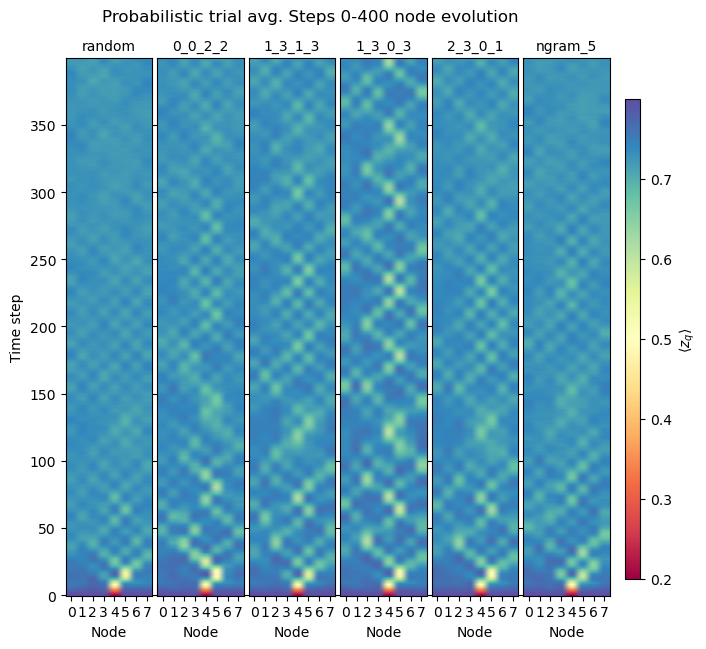

In [182]:
steps_range = (0,400)
fig, axs = plot_all_node_evol_heatmaps(pops_NM_all, steps_range=steps_range)
fig.suptitle(f'Probabilistic trial avg. Steps {steps_range[0]}-{steps_range[1]} node evolution',y=1.05)
plt.show()

/var/folders/xr/spzdt0tj3zj_ns139lpchs1w0000gn/T/ipykernel_77930/4138080042.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.0)


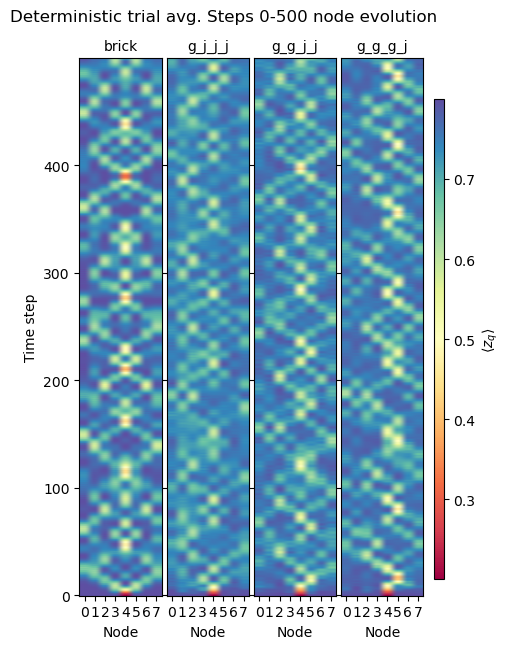

In [184]:
steps_range = (0,500)
fig, axs = plot_all_node_evol_heatmaps(pops_NM_det, steps_range=steps_range)
fig.suptitle(f'Deterministic trial avg. Steps {steps_range[0]}-{steps_range[1]} node evolution',y=1.05)
plt.show()

# $\tau_z$ statistics

In [70]:
def tz_two_q_dyns_map(pops_trial_index, denom = 15.0):
    tz = []
    pops_trial_index = np.array(pops_trial_index)
    num_steps, _ = pops_trial_index.shape
    for step_index in range(num_steps - 1):
        tzi =  np.sin(np.pi/denom)*np.sin(np.pi/denom) -2*(pops_trial_index[step_index + 1 ] - np.cos(np.pi / denom)*np.cos(np.pi / denom)* pops_trial_index[step_index])
        tz.append(tzi)
    return tz

def abs_tz(pops,denom):
    abs_tz=[]
    for step in tz_two_q_dyns_map(pops,denom):
        abs_step = [abs(ele) for ele in step]
        abs_tz.append(abs_step)
    return abs_tz

def CPcond(abs_tz_pops, denom=15.0) :
    cp_cond=[]
    for step in abs_tz_pops:
        cp_step = [ele + np.cos(np.pi / denom) * np. cos(np.pi / denom)  for ele in step]
        cp_cond.append(cp_step)
    return cp_cond

def means_stds_of_tz_of_one_sim_index(tz_trial_index, num_steps):
    mean_stds_list = []
    for step_index in range(num_steps):
        stds = np.std(tz_trial_index [step_index])
        means = np.mean(tz_trial_index[step_index])
        mean_stds_list.append([means, stds])
    return mean_stds_list

In [56]:
def tau_z_avg_over_trials(pops, denom = 15.0):
    ''' 
    Calculates tau_z, then takes LATE-TIME average over each trial for tau_z values. 

    Paramters
    ---------
    pops : array
        Array of populations, with dimensions for (trials, timesteps, qubits)
    denom : float
        Denominator value for pi/denom in trig functions within unitary.
    
    Returns
    -------
    DataFrame of tau_z values, averaged over trials, cols for qubits, rows for
    timesteps. 
    '''
    tz_avg = np.zeros((pops[:,300:,:].shape[1]-1, pops.shape[2]))

    # sum tau_z stats for each trial 
    for trial_pops in pops: 
        trial_pops = trial_pops[300:,:] # take late-time values only
        tau_z_pops = np.array(tz_two_q_dyns_map(trial_pops, denom = denom)) 
        tz_avg = np.add(tz_avg, tau_z_pops)

    # divide by number of trials to obtain average values
    tz_avg = tz_avg / float(pops.shape[0])

    # cast results into DataFrame
    col_names = [f'qubit {i+1}' for i in range(n_qubits)]
    return pd.DataFrame(tz_avg, columns=col_names)

def plot_tau_z_dist(df, ax, title='',legend=False, y_label=''): 
    sns.kdeplot(data=df, lw=1.0, 
                ax=ax,  
                legend=legend)
    ax.set(xlabel=r'$\tau_z$',
        ylabel=y_label,
        title=rf'$\tau_z$ distribution for {title}')
    
    # place text box with statistics 
    means = list(df.mean(axis=0))
    kurtosis = list(df.kurtosis(axis=0))
    skewness = list(df.skew(axis=0))

    textstr = '\n'.join((
        rf'$\sigma(\mu)=${np.std(means):.3f}',
        rf'$\sigma$(kurtosis)={np.std(kurtosis):.3f}',
        rf'$\sigma$(skew)={np.std(skewness):.3f}'
        ))

    # these are matplotlib.patch.Patch properties
    props = dict(boxstyle='round', facecolor='white', edgecolor='grey',alpha=0.5)

    # place a text box in upper left in axes coords
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    

In [71]:
def plot_all_tau_z_avg_over_trials(pops_NM_all, nrows=2):
    tz_trial_avg_dfs = {}
    for rule_name in pops_NM_all: 
        tz_trial_avg_dfs[rule_name] = tau_z_avg_over_trials(pops_NM_all[rule_name])

    n_plots_tau_z = len(tz_trial_avg_dfs)
    ncols = int(np.ceil(n_plots_tau_z / nrows))

    fig, axs = plt.subplots(nrows, ncols, 
                        figsize=(ncols*5,nrows*5),
                        sharey=True,sharex=True)

    # TODO: try this in another way so that it represents sigma(kurtosis) for each trial, not for each qubit??

    # plot
    
    for i,rule_name in enumerate(tz_trial_avg_dfs):
        row = i // ncols
        col = i % ncols
        plot_tau_z_dist(tz_trial_avg_dfs[rule_name],ax=axs[row,col],
                        title=f'{rule_name}',
                        legend = (i == len(tz_trial_avg_dfs)-1), # only create legend on last plot
                        y_label='Density')

    # turn off subplots that have no data
    all_axs = axs.flatten()
    for ax in all_axs:
        if not ax.has_data():
            ax.set_visible(False)

    # layout, title
    plt.tight_layout(pad=1.5)
    plt.suptitle(r'Non-Markovian gate seqs trial-averaged $\tau_z$ distribution',fontsize=16,y=1.05)

    # save figure as .png
    plt.savefig(FIGURES_FILEPATH + 'tau_z_dist_compare_rules.png',dpi=200, bbox_inches='tight')


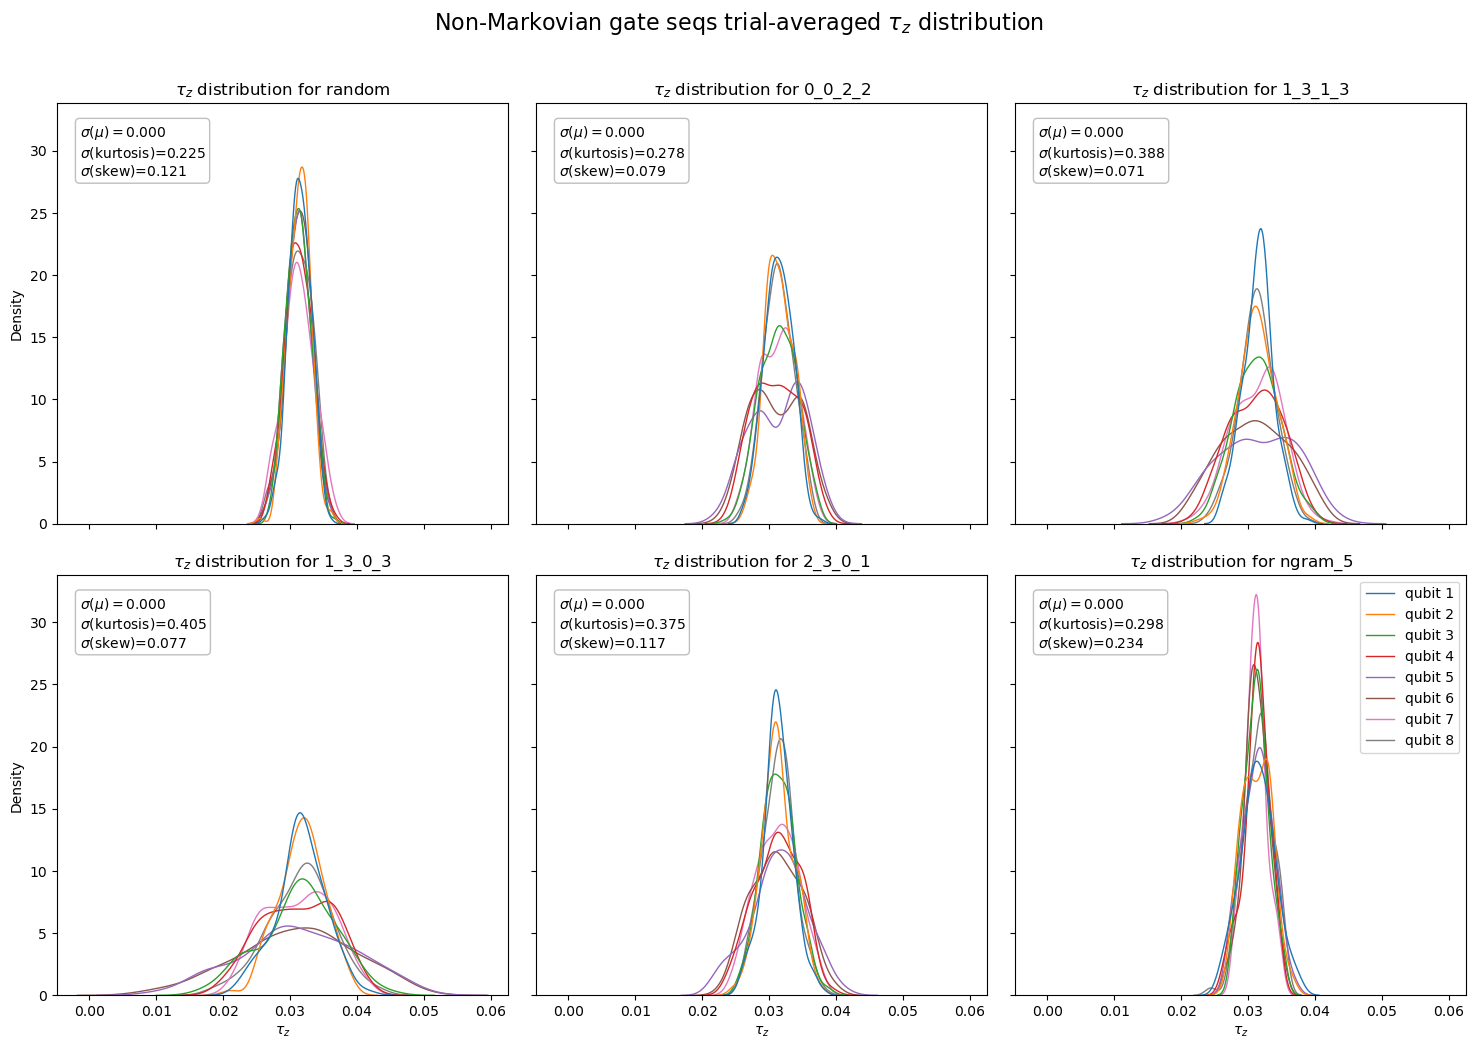

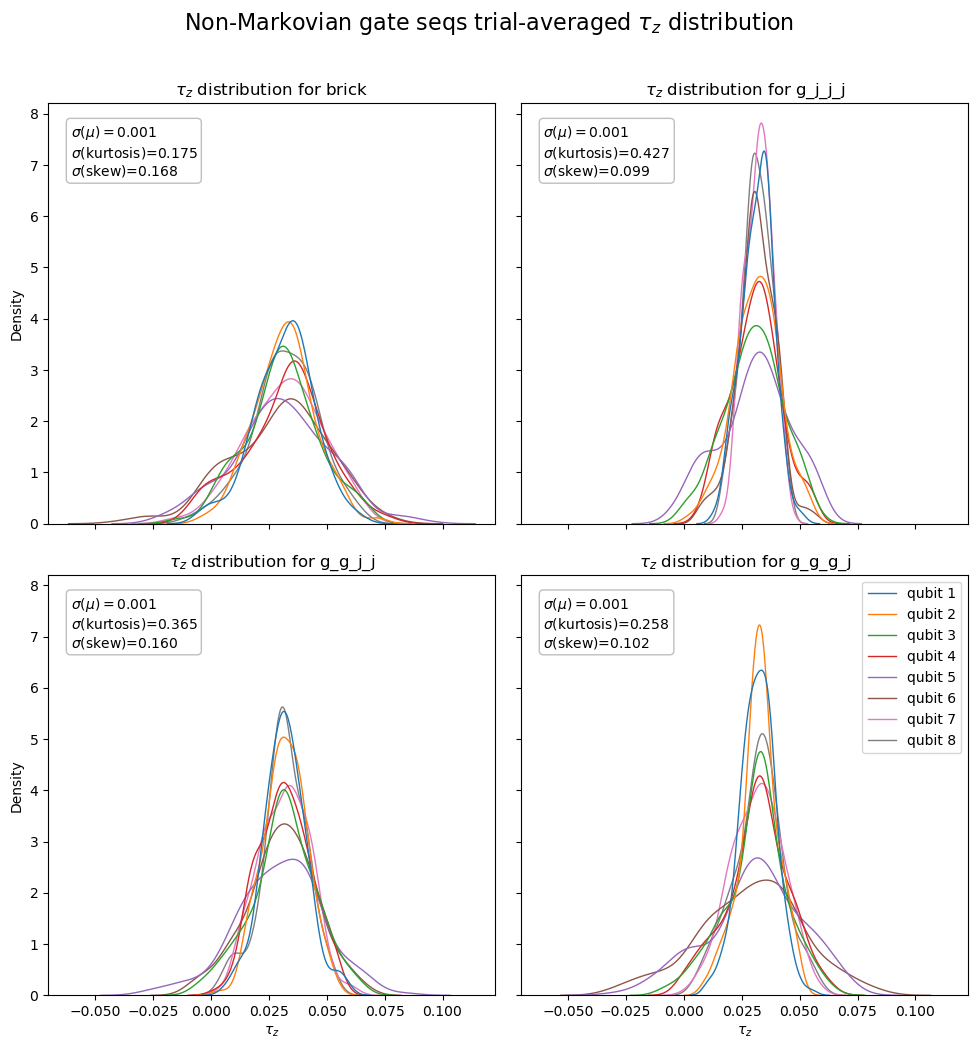

In [72]:
plot_all_tau_z_avg_over_trials(pops_NM_all)
plot_all_tau_z_avg_over_trials(pops_NM_det)

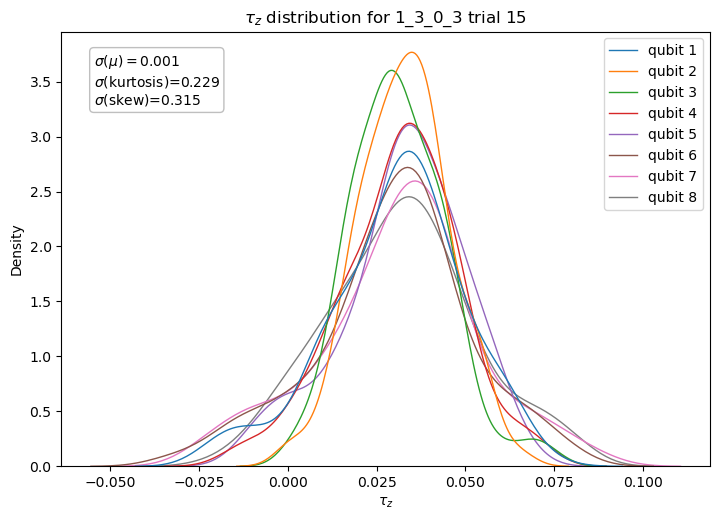

In [42]:
# plot tau_z distribution for individual trials
rule_name = list(newdata_all.keys())[3] 
trial_idx = random.randint(0,num_trials-1)

def tau_z_single_trial_plot(rule_name, trial_idx): 
    # use only pops from late time (steps 300 onwards) from one trial (trial_idx)
    tz_trial_to_plot = pd.DataFrame(data=tz_two_q_dyns_map(pops_NM_all[rule_name][trial_idx,300:,:]),
                                    columns=[f'qubit {i+1}' for i in range(n_qubits)])

    fig, ax = plt.subplots(1,1,
                        figsize=(1*7,5),
                        sharey=True,sharex=True)

    plot_tau_z_dist(tz_trial_to_plot,ax=ax,
                        title=f'{rule_name} trial {trial_idx}',
                        legend = True,
                        y_label='Density')
    plt.tight_layout(pad=0)

    plt.savefig(FIGURES_FILEPATH + 'tau_z_dist_one_trial_{rule_name}.png',dpi=200, bbox_inches='tight')


tau_z_single_trial_plot(rule_name,trial_idx)
# interesting: 
# 45, 53 -- nearly thermal
# 74, 85, -- most others are non-thermal 
# NEW!!!

In [73]:
def compare_tau_z_by_init_seq(pops, num_init, trials_per_init, rule_name):
    # 100 is number of trials, there are 25 trials for each initial gate seq
    trial_range = list(range(0,(num_init+1)*trials_per_init, trials_per_init)) 

    # do averaging over trials by initial gate seq
    tau_z_avg_dfs_by_init_seq = [tau_z_avg_over_trials(pops[x:trial_range[i+1]]) for i,x in enumerate(trial_range[:-1])]

    # plot
    fig, ax = plt.subplots(1,4,figsize=(4*6,5),sharey=True,sharex=True)
    for i, df in enumerate(tau_z_avg_dfs_by_init_seq):
        plot_tau_z_dist(df,ax=ax[i],title=f'init seq {i+1}')
        
        # place text box with statistics 
        means = list(df.mean(axis=0))
        kurtosis = list(df.kurtosis(axis=0))
        skewness = list(df.skew(axis=0))

        textstr = '\n'.join((
            rf'$\sigma(\mu)=${np.std(means):.3f}',
            rf'$\sigma$(kurtosis)={np.std(kurtosis):.3f}',
            rf'$\sigma$(skew)={np.std(skewness):.3f}'
            ))

        # these are matplotlib.patch.Patch properties
        props = dict(boxstyle='round', facecolor='white', edgecolor='grey',alpha=0.5)

        # place a text box in upper left in axes coords
        ax[i].text(0.05, 0.95, textstr, transform=ax[i].transAxes, fontsize=10,
                verticalalignment='top', bbox=props)

    plt.suptitle(rf'$\tau_z$ distribution for rule {rule_name} by init seq',y=1.05,fontsize=20)
    plt.tight_layout(pad=0)
    plt.savefig(f'{FIGURES_FILEPATH}tau_z_dist_compare_init_{rule_name}.png',dpi=200, bbox_inches='tight')

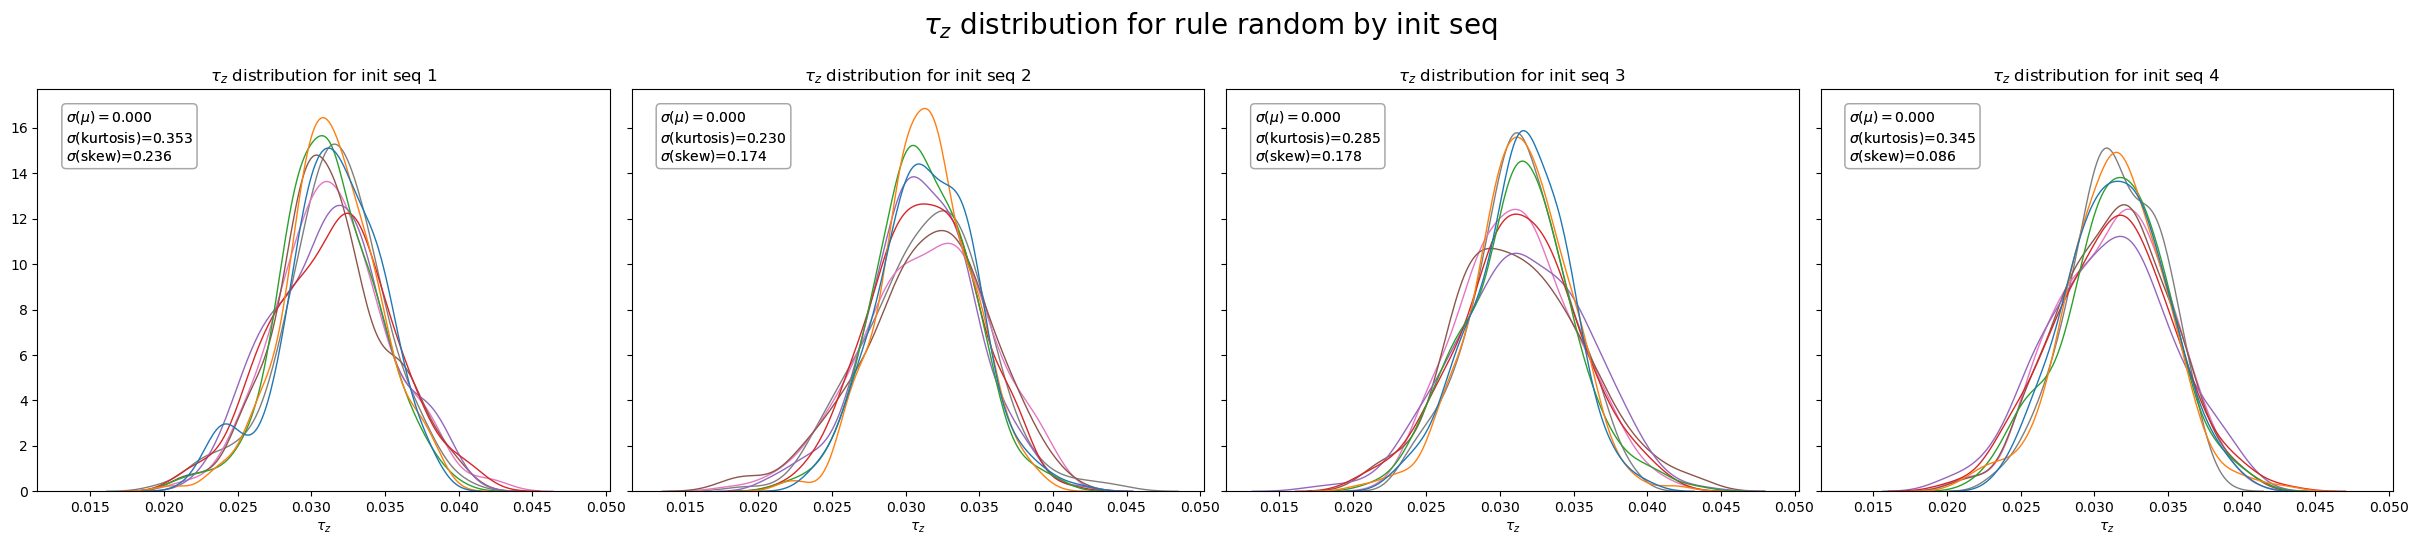

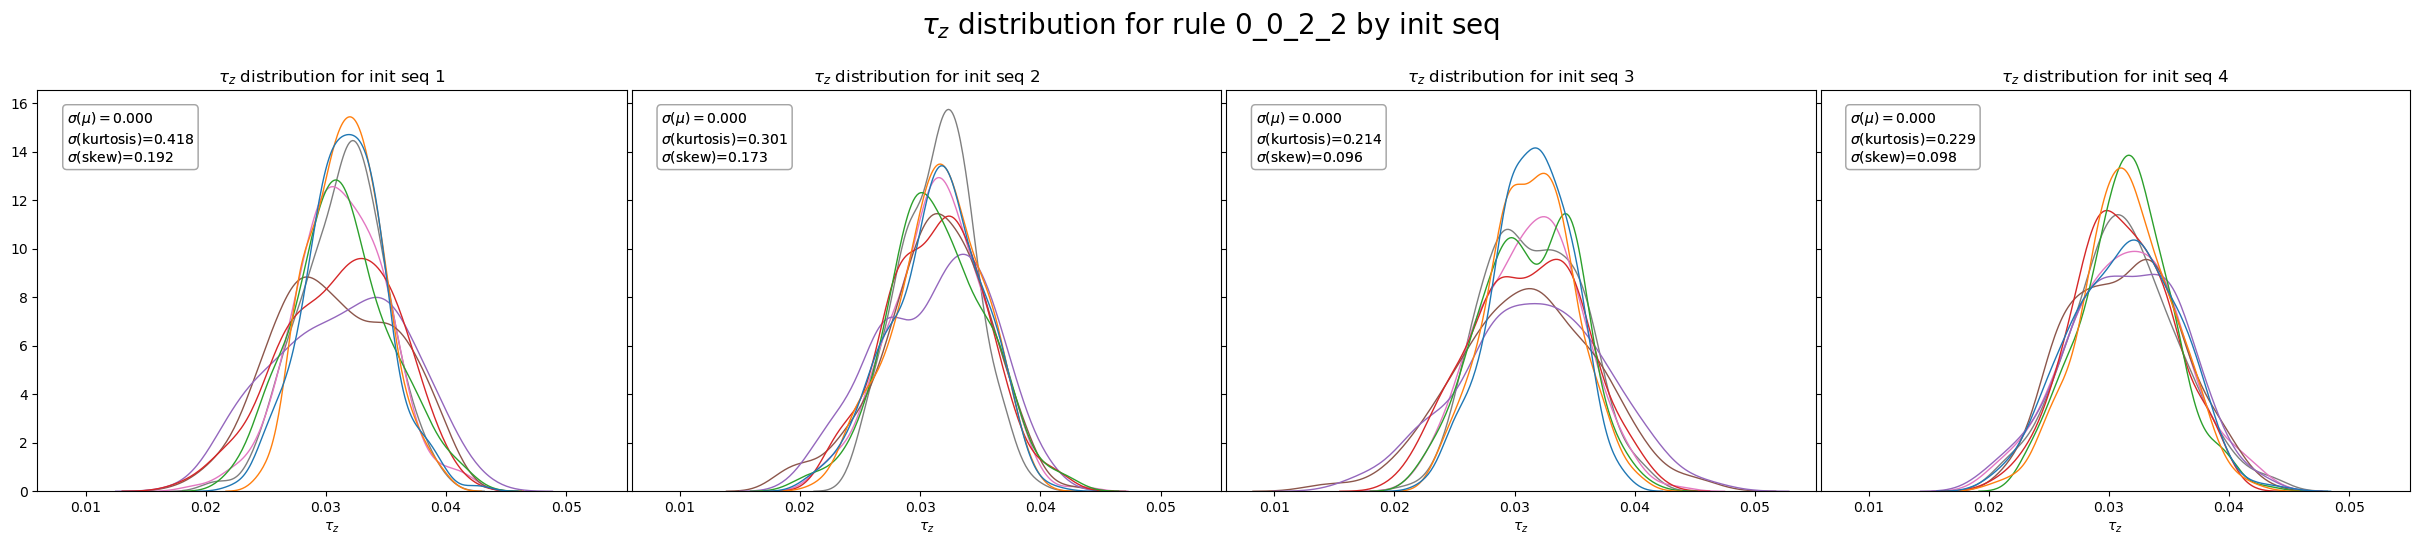

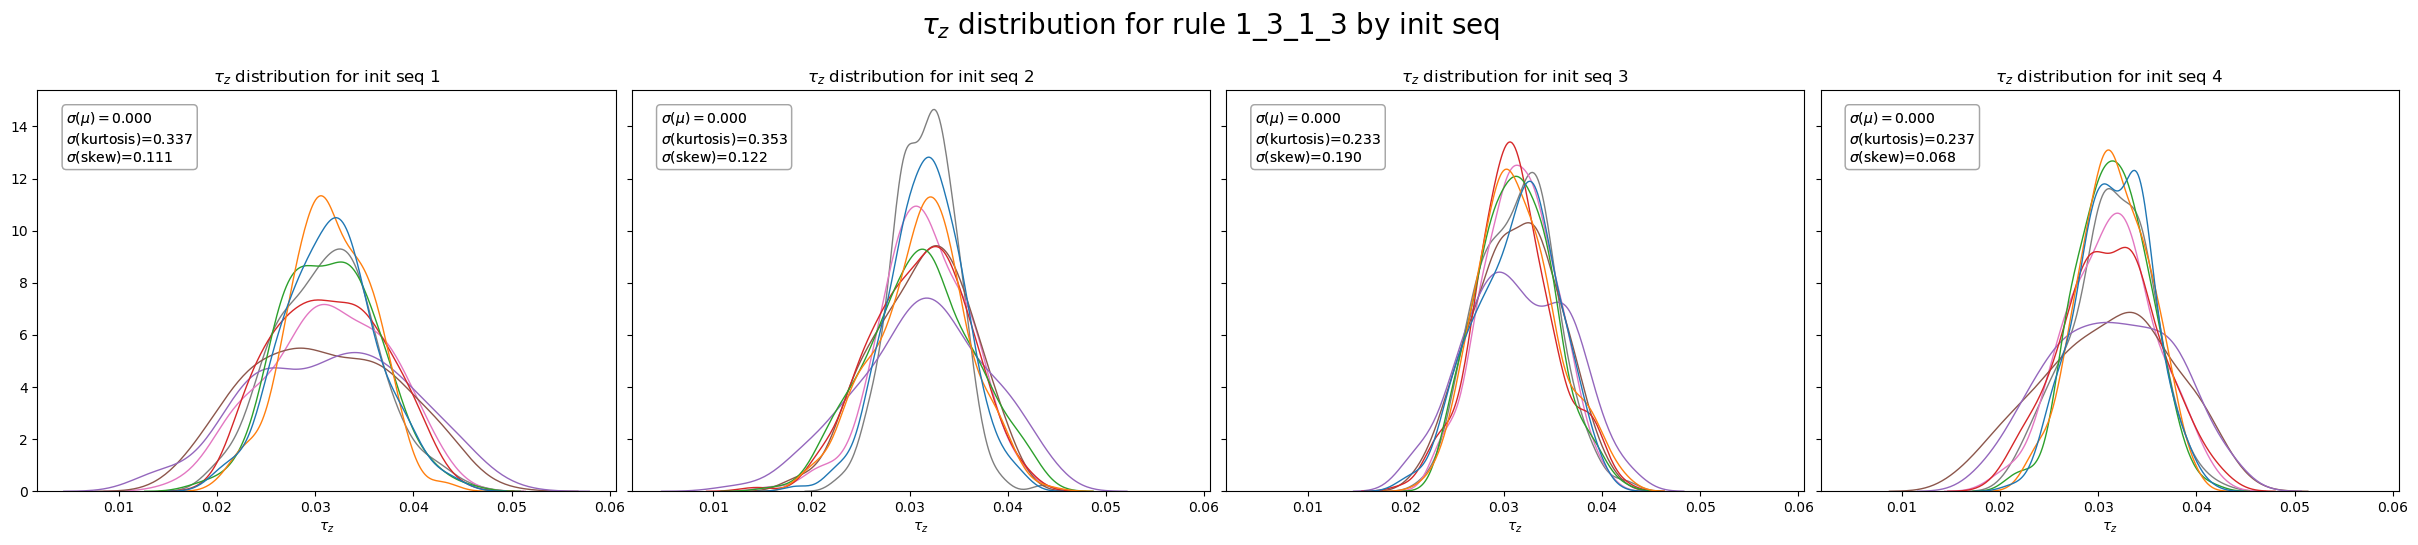

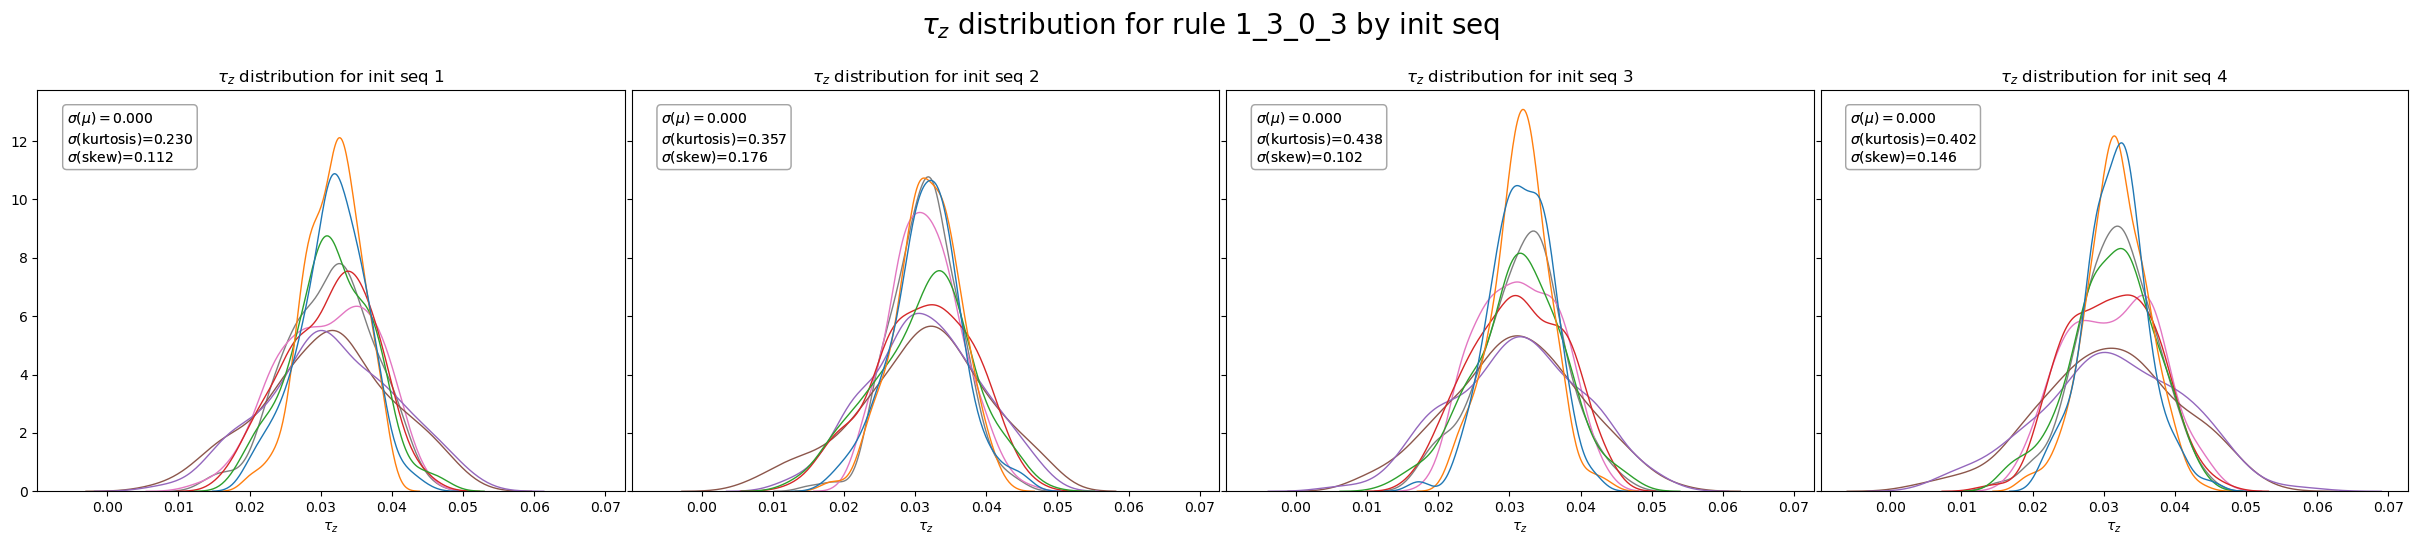

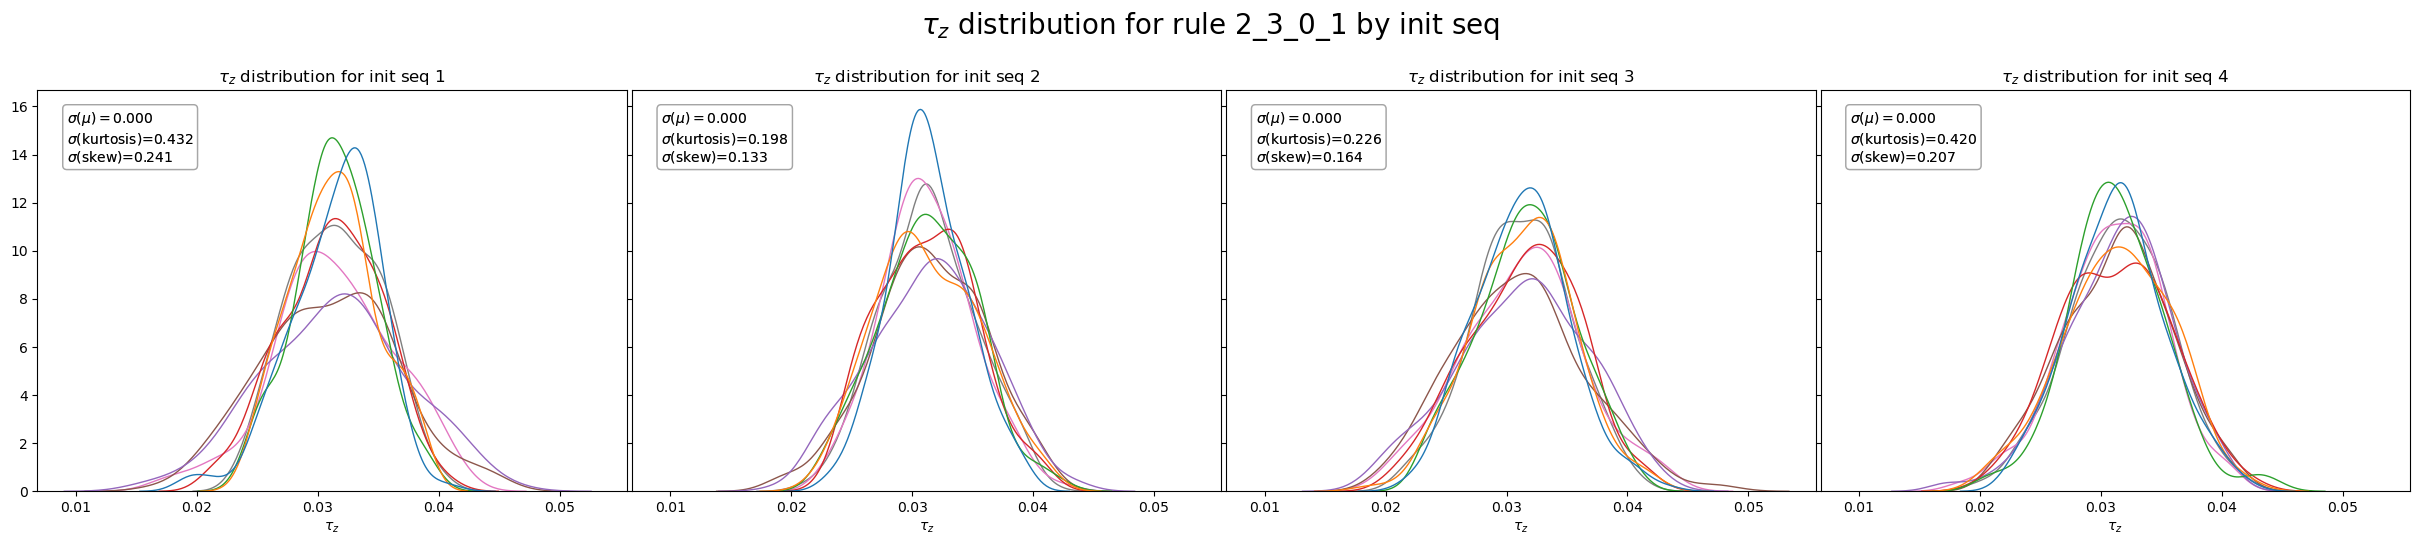

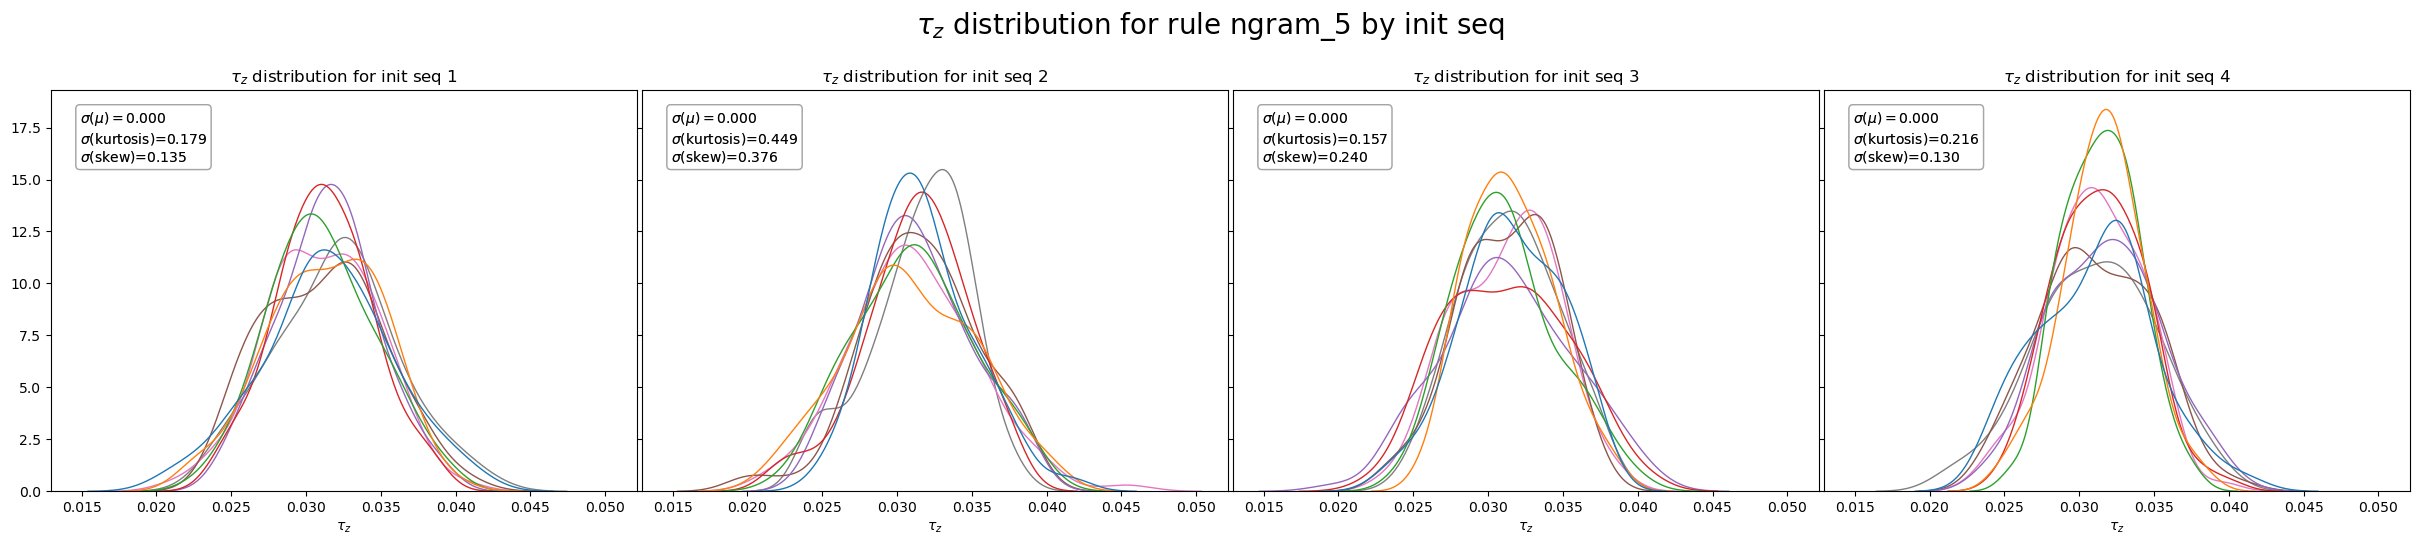

In [74]:
for rule_name in pops_NM_all:
    compare_tau_z_by_init_seq(pops = pops_NM_all[rule_name], 
                            num_init = 4, trials_per_init = 25,
                            rule_name = rule_name)

g_j_j_j
gjjgjjgjjgjjgjjgjjgj
jjgjjgjjgjjgjjgjjgjj
jgjjgjjgjjgjjgjjgjjg
jjgjjgjjgjjgjjgjjgjj
g_g_j_j
ggjjggjjggjjggjjggjj
gjjggjjggjjggjjggjjg
jggjjggjjggjjggjjggj
jjggjjggjjggjjggjjgg
g_g_g_j
ggjggjggjggjggjggjgg
gjggjggjggjggjggjggj
ggjggjggjggjggjggjgg
jggjggjggjggjggjggjg


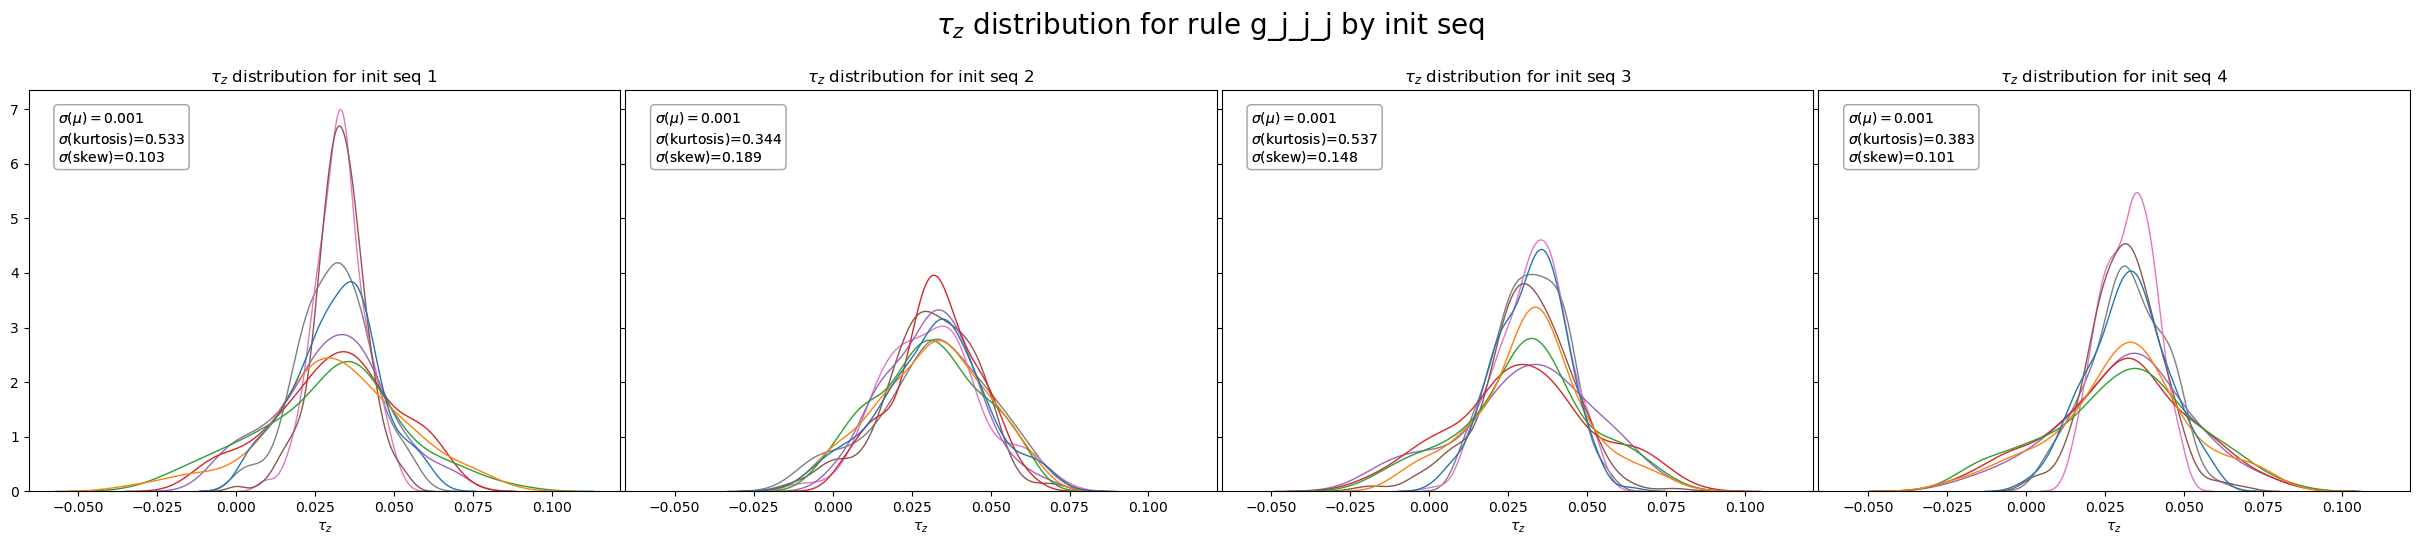

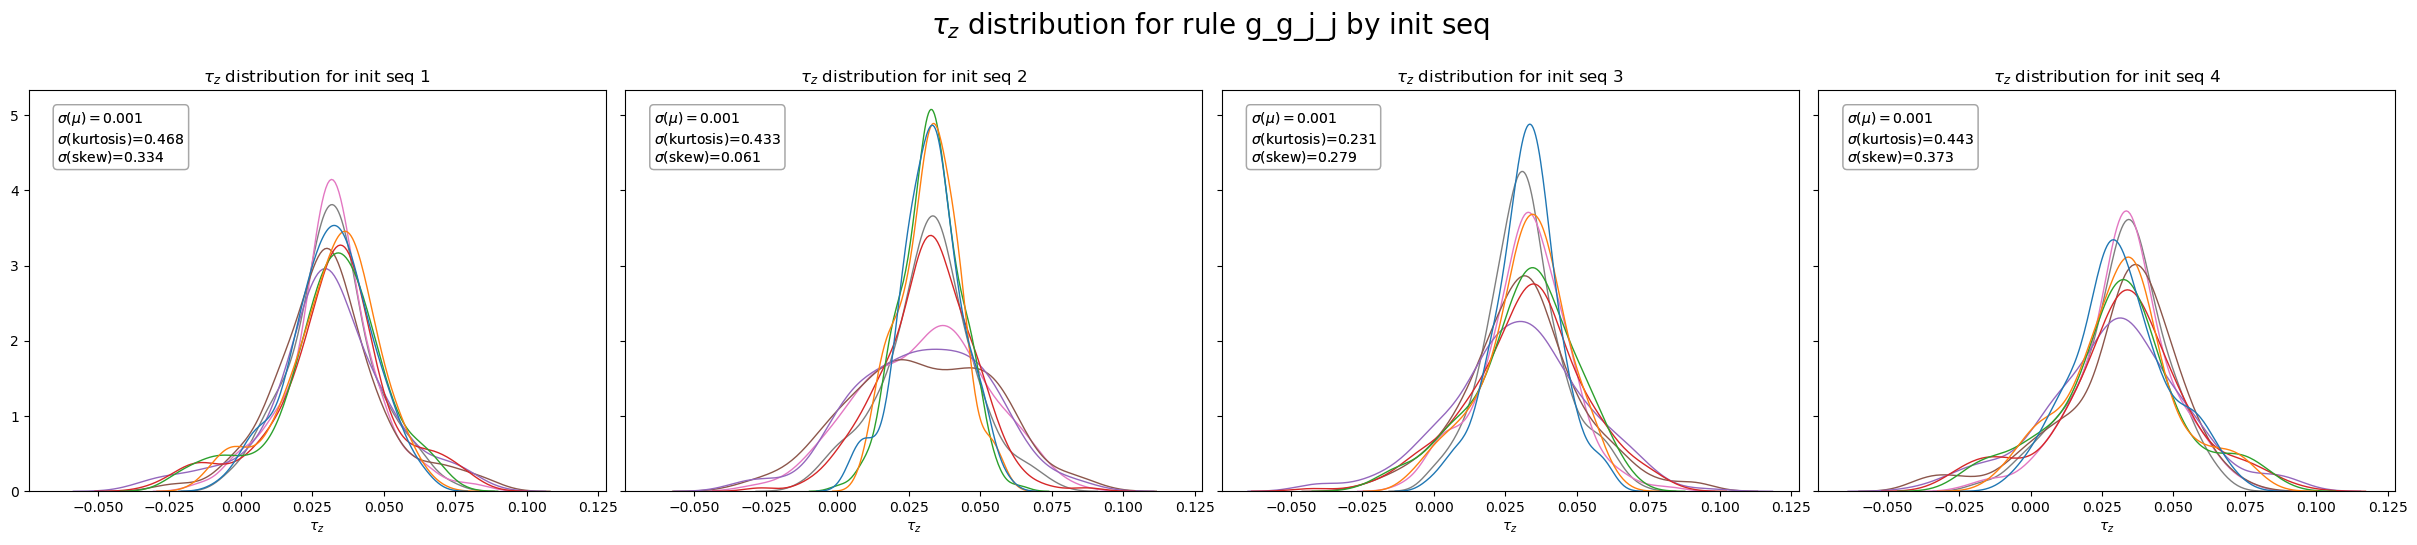

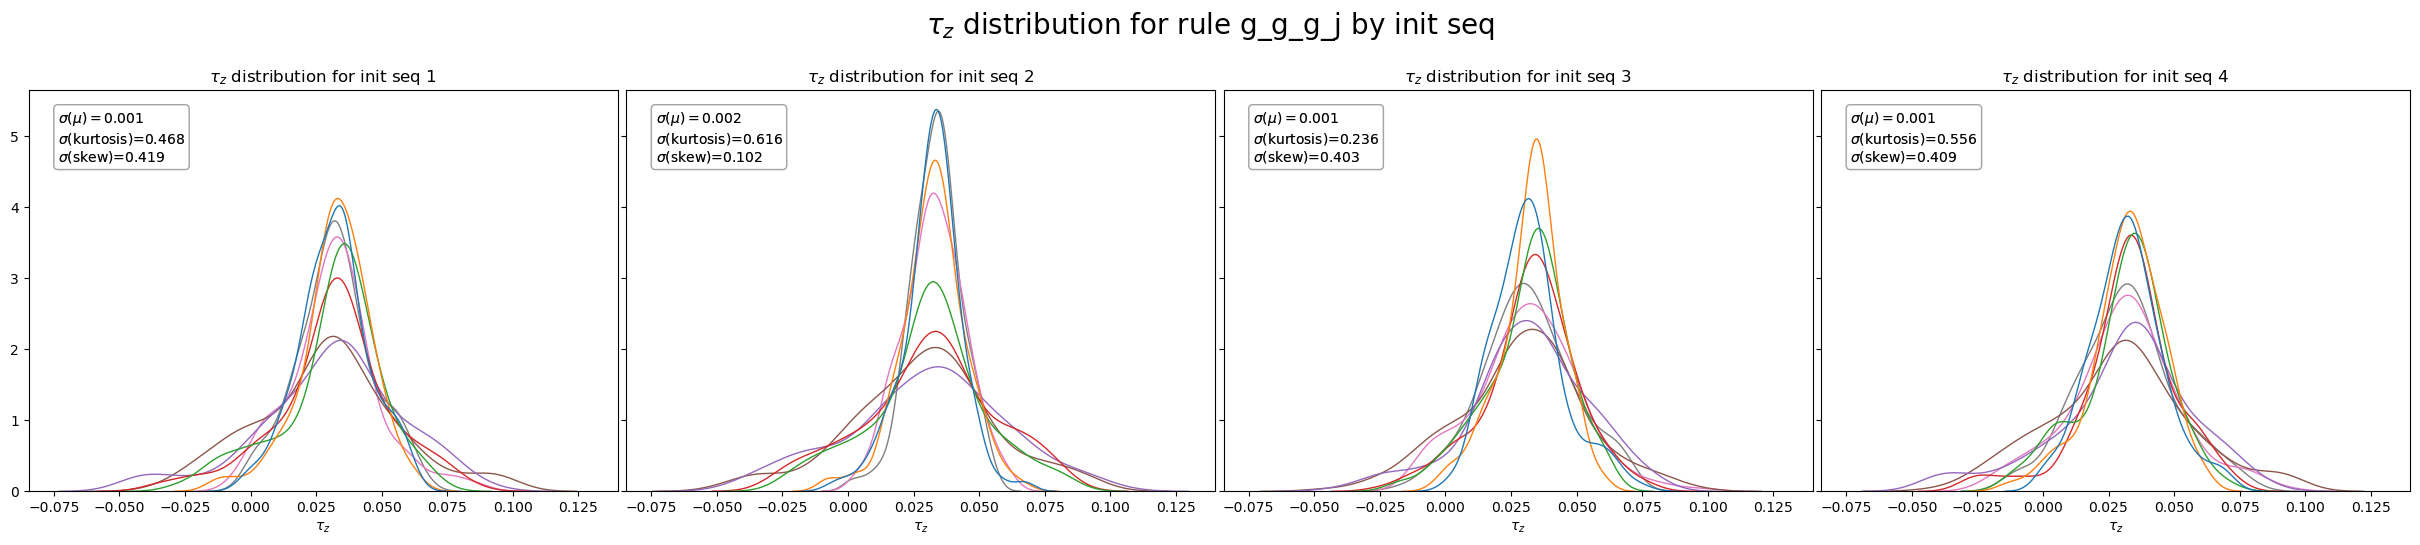

In [83]:
for rule_name in pops_NM_det:
    if rule_name != 'brick':
        compare_tau_z_by_init_seq(pops = pops_NM_det[rule_name], 
                                num_init = 4, trials_per_init = 1,
                                rule_name = rule_name)
        print(rule_name)
        exec(f'rules = NM_list_{rule_name}')
        for rule in rules:
            print(rule[-20:])

In [80]:
def tau_z_tot_avg_plot(pops, ax, title=''):
    pops = pops[:,300:,:] # taking 300th steps and onwards

    tz_arr = np.array([])
    for trial_pops in pops: 
        tau_z_pops = np.array(tz_two_q_dyns_map(trial_pops)) 
        tz_arr = np.append(tz_arr, tau_z_pops)

    # ax = sns.histplot(data=tz_arr, kde=False, stat='density',bins=50, color='grey')
    sns.histplot(data=tz_arr, kde=False, stat='density',bins=100, color='#63806a', edgecolor='#445c4a', ax=ax)
    sns.kdeplot(data=tz_arr, color='g', alpha=1, lw=1.5, ax=ax)

    ax.axvline(np.mean(tz_arr),linestyle='dashed',lw=2,c='r')
    
    # place text box 
    textstr = '\n'.join((
        rf'$\mu=${np.mean(tz_arr):.3f}',
        rf'$\sigma=${np.std(tz_arr):.3f}',
        rf'kurtosis={kurtosis(tz_arr):.3f}',
        rf'skew={skew(tz_arr):.3f}'
        ))

    # these are matplotlib.patch.Patch properties
    props = dict(boxstyle='round', facecolor='white', edgecolor='grey',alpha=0.5)

    # place a text box in upper left in axes coords
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    ax.set(xlabel=r'$\tau_z$',
        title=rf'all $\tau_z$ distribution for {title}')
    
    plt.tight_layout(pad=0.0)
    
    plt.savefig(f'{FIGURES_FILEPATH}tau_z_dist_all_{title}.png',dpi=200)

    return tz_arr

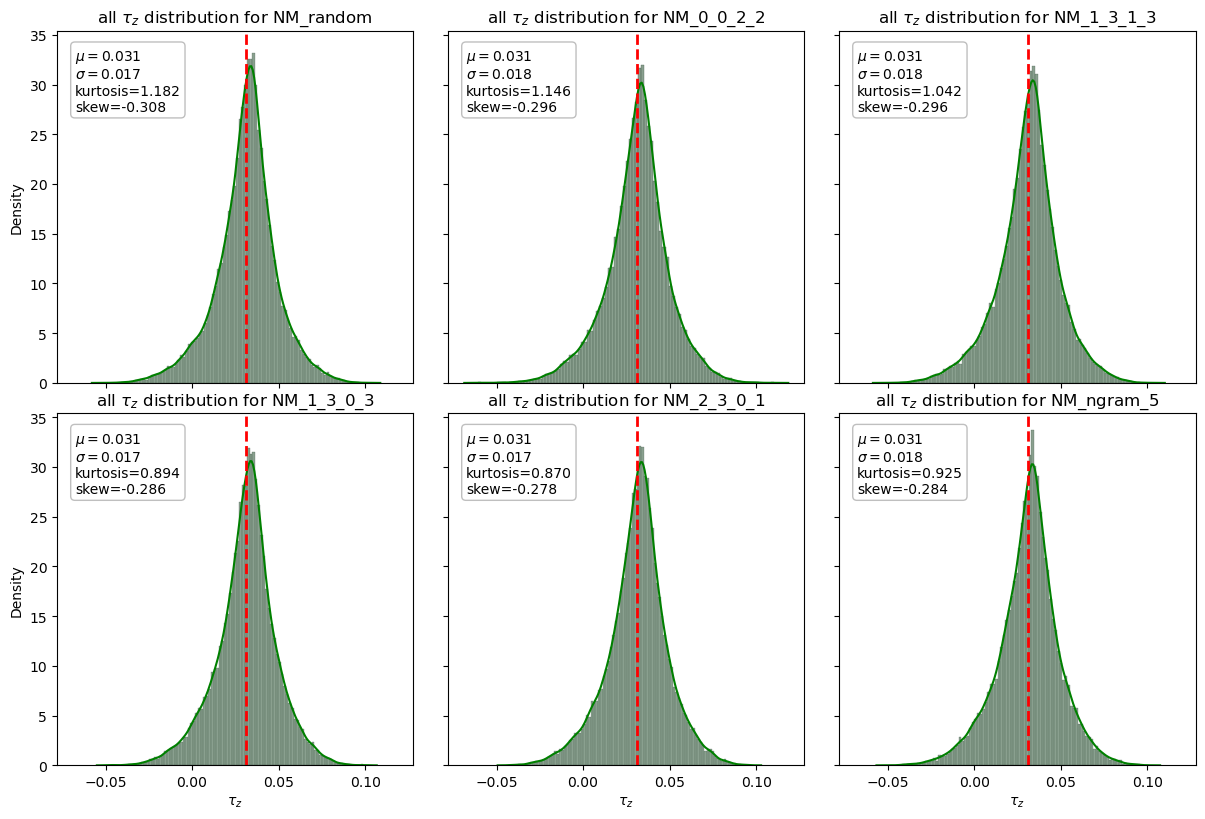

In [81]:
nrows = 2
ncols = int(np.ceil(len(pops_NM_all)/2))
fig, axs = plt.subplots(nrows,ncols,figsize=(ncols*4,nrows*4),
                        sharey=True,sharex=True)
for i,rule_name in enumerate(pops_NM_all.keys()): 
    row = i // ncols
    col = i % ncols
    tau_z_tot_avg_plot(pops_NM_all[rule_name][:25], ax=axs[row][col], title=f'NM_{rule_name}')

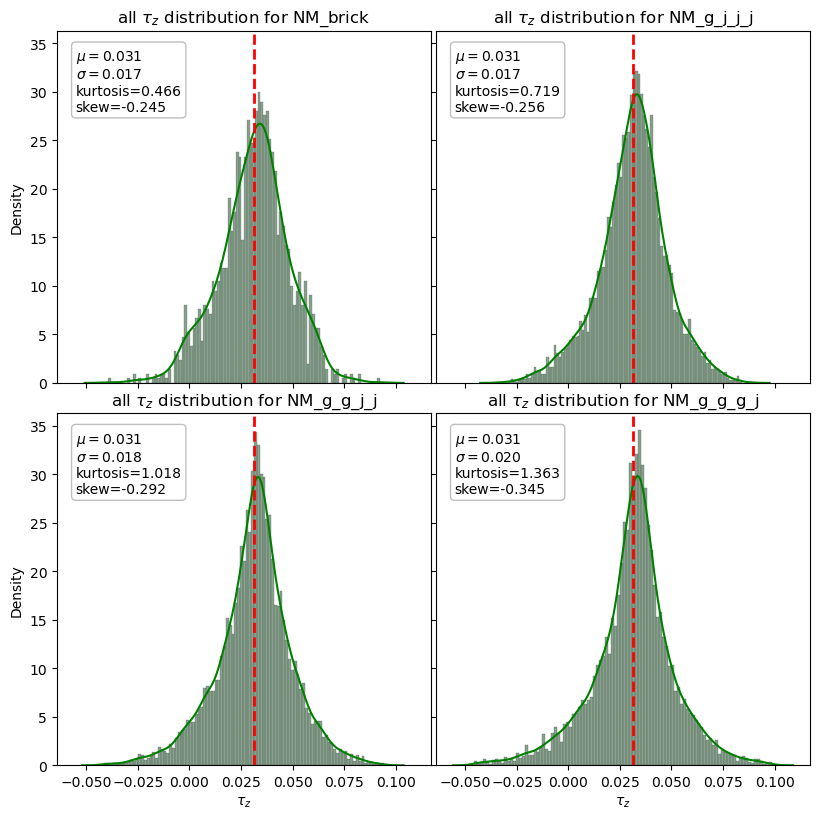

In [82]:
nrows = 2
ncols = int(np.ceil(len(pops_NM_det)/2))
fig, axs = plt.subplots(nrows,ncols,figsize=(ncols*4,nrows*4),
                        sharey=True,sharex=True)
for i,rule_name in enumerate(pops_NM_det.keys()): 
    row = i // ncols
    col = i % ncols
    tau_z_tot_avg_plot(pops_NM_det[rule_name][:25], ax=axs[row][col], title=f'NM_{rule_name}')

In [105]:
def time_averaged_one_point_measures_at_t(dataset,t):
    '''
    Takes in dataset for one trial. Takes ensemble average along the first axis
    (averaging over all datasets). 

    Parameters
    ----------
    - dataset : list of n lists, for n time steps, in total corresponding to 
        one trial. 
    - t : int, cutoff time step. 

    Returns
    -------
    - dataset averaged over time axis
    '''

    sum_till_t = np.sum(dataset[:t], axis=0)
    time_average_t = (1/(t+1))*(sum_till_t)

    return (time_average_t)

def time_averaged_one_point_measures_matrix_full_sim(dataset):
    # Take the ensemble average along the first axis (averaging over all datasets)
    ''' 
    Take the ensemble average along the first axis (averaging over all datasets).
    '''
    time_average=[]
    for t in range(len(dataset)):
        time_average.append(time_averaged_one_point_measures_at_t(dataset,t))

    return (time_average)

def plot_connectivity(
    pops_list,
    seed=50,
    denom=15,
    ytherm12=(0.1*11+0.4)/12,  # Default value, adjust as needed
    colors=None,
    dataset_label=None,
    population_titles = ["$R_{1}$", "$R_{2}$", "$R_{3}$", "$R_{4}$", "$R_{5}$"],
    start_t = 10,
    stop_t = 499,
    nrows = 2,
):
    """
    Create a 2x5 grid of plots comparing C2 and C4 connectivity for different populations.

    Parameters
    ----------
    pops_list : list[array]
        Each array is populations from get_pops().
    seed : int
        Seed to use for time-averaged plots
    denom : int
        Denominator value for calculations
    ytherm10 : float
        Thermal value for reference line
    colors : list
        List of colors to use for plotting
    dataset_label : str
        Label to use in saved filenames. If None is given, plot will not save.
    """
    if colors is None:
        colors = ["#3395EB", "#F38F2C", "#4D9B26", "#FF98CA", "#6F27FF","#E8C854", "#098282", "#D4A2ED", '#D04E00', '#A8E6CF','#FFDAB9', '#B2B09C']

    # Create figure with GridSpec for better control
    ncols = int(np.ceil(len(pops_list)/nrows))
    fig, axs = plt.subplots(nrows,ncols,
                            figsize=(4*ncols, 4*nrows),sharey=True,sharex=True)

    # Function to create time-averaged plot
    def create_time_averaged_plot(ax, pops, pop_idx, conn, title, start_t, stop_t):
        data = time_averaged_one_point_measures_matrix_full_sim(tz_two_q_dyns_map(pops[pop_idx][seed], denom))

        data = np.array(data[start_t:stop_t])
        t = np.arange(start_t,stop_t)
        data_transposed = data.T

        # plot data onto ax
        for i, y_values in enumerate(data_transposed):
            color = colors[i % len(colors)]
            ax.plot(t, y_values, label=f'$Q_{{{i+1}}}$', color=color, linewidth=1.0)

        # plot ytherm
        tau_z_star = (1-2*ytherm12)*(np.sin((np.pi)/denom))**2
        ax.axhline(y=tau_z_star, color='r', linestyle='--',
                label=r'$\tau_z^*$'f' = {tau_z_star:.3f}')

        # Set consistent number of y-axis ticks (e.g., 5 ticks)
        ax.yaxis.set_major_locator(plt.MaxNLocator(10))

        # set axis titles 
        ax.set_title(f'{title}', fontsize=16)
            
        # x-axis limit
        ax.set_xlim(start_t,stop_t)
        
        ax.grid(True)
        
    # create subplots
    for pop_idx in range(len(pops_list)):
        row, col = pop_idx // ncols, pop_idx % ncols
        ax = axs[row,col]
        create_time_averaged_plot(ax, pops_list, pop_idx, "C2", population_titles[pop_idx],start_t,stop_t)
        if row == nrows - 1: # only set x-label on last row
            ax.set_xlabel(r'$\ell$', fontsize=12)
        if col == 0: # only set y-label on first column
            ax.set_ylabel(r'$\langle \tau_{z} \rangle _\ell$', fontsize=12)
    
    # create legend
    handles, labels = axs[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, 
            fontsize=10,ncols=5, 
            loc='upper center',bbox_to_anchor=(0.5,0.0))

    # enforce tight layout
    plt.tight_layout(pad=0.0)
        

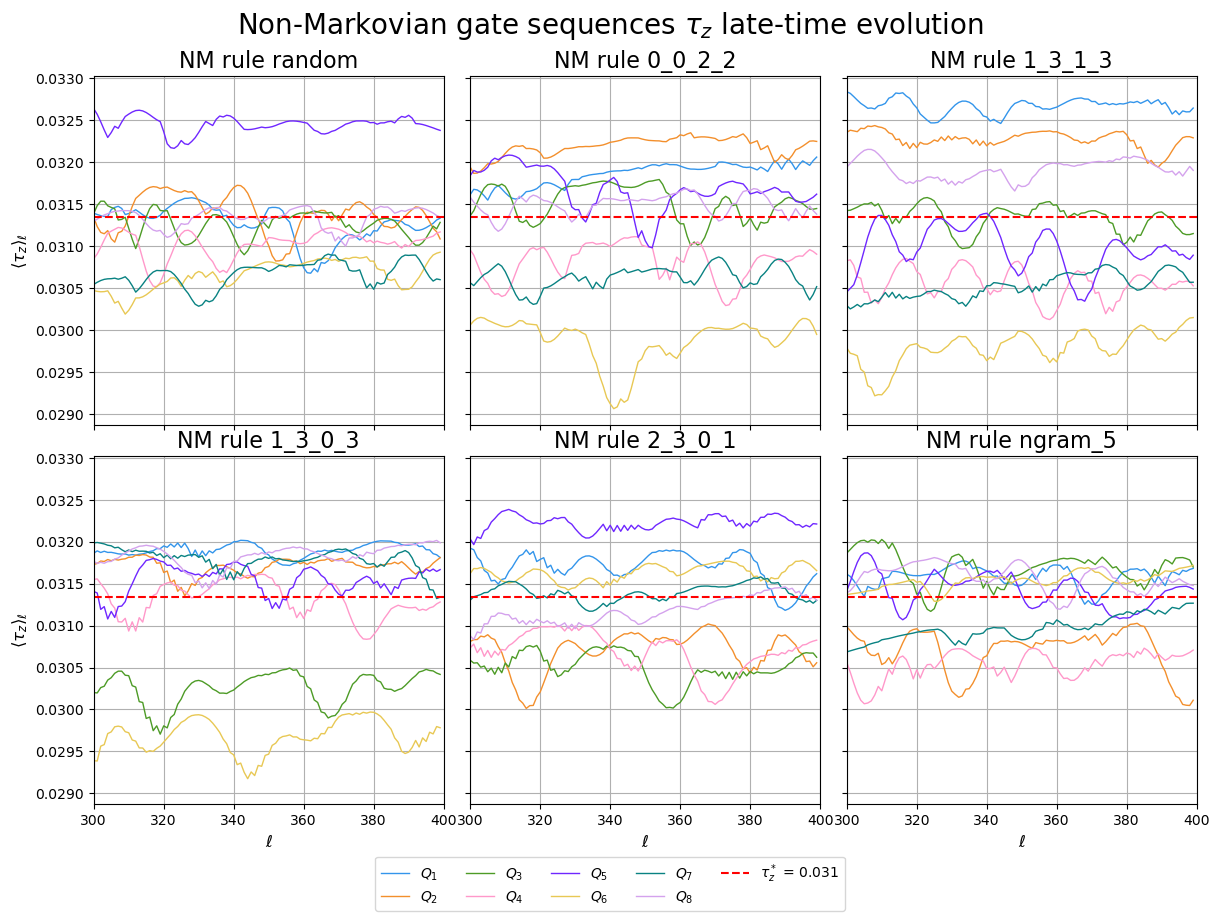

In [106]:
pops_list = list(pops_NM_all.values())

# Call the function with seed=50
plot_connectivity(
    pops_list,
    seed=4,
    ytherm12=np.mean([0.1,0.1,0.1,0.1,0.4,0.1,0.1,0.1]),  # Adjust this value as needed
    population_titles = [f'NM rule {rule_name}' for rule_name in pops_NM_all],
    start_t = 300,
    stop_t = 400
)
plt.suptitle(r'Non-Markovian gate sequences $\tau_z$ late-time evolution',fontsize=20, y = 1.05)
plt.savefig(f'{FIGURES_FILEPATH}tz_comparison_NonMarkovian.pdf', format='pdf', bbox_inches='tight')

Text(0.5, 1.05, 'Deterministic gate sequences $\\tau_z$ late-time evolution')

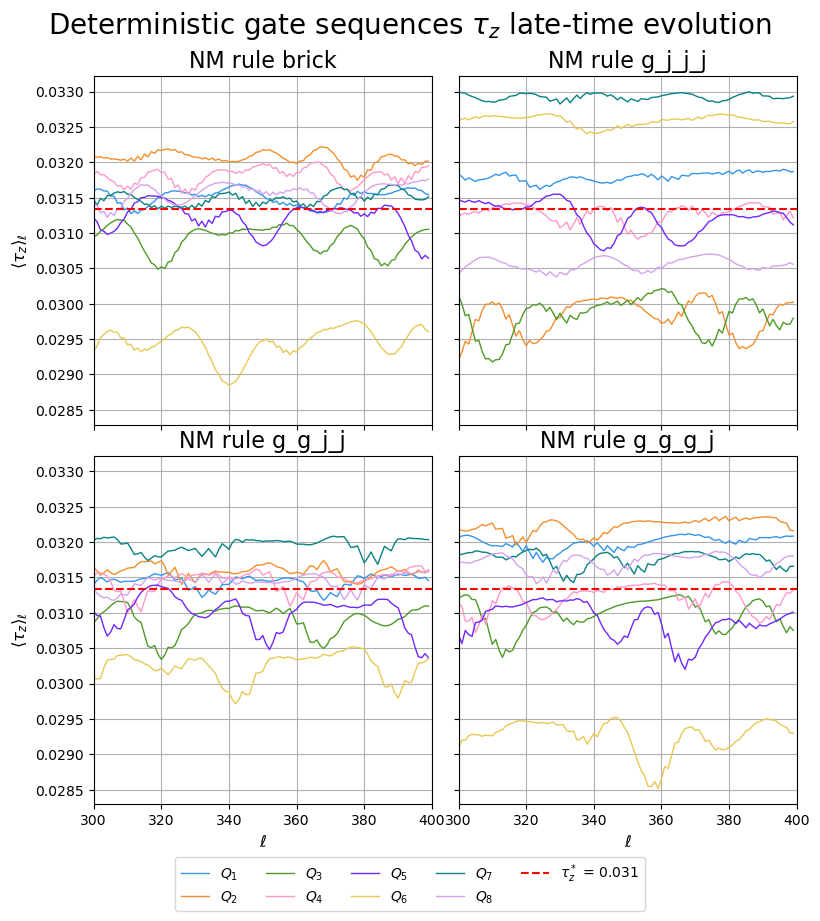

In [107]:
pops_list = list(pops_NM_det.values())

# Call the function with seed=50
plot_connectivity(
    pops_list,
    seed=0,
    ytherm12=np.mean([0.1,0.1,0.1,0.1,0.4,0.1,0.1,0.1]),  # Adjust this value as needed
    population_titles = [f'NM rule {rule_name}' for rule_name in pops_NM_det],
    start_t = 300,
    stop_t = 400
)
plt.suptitle(r'Deterministic gate sequences $\tau_z$ late-time evolution',fontsize=20, y = 1.05)

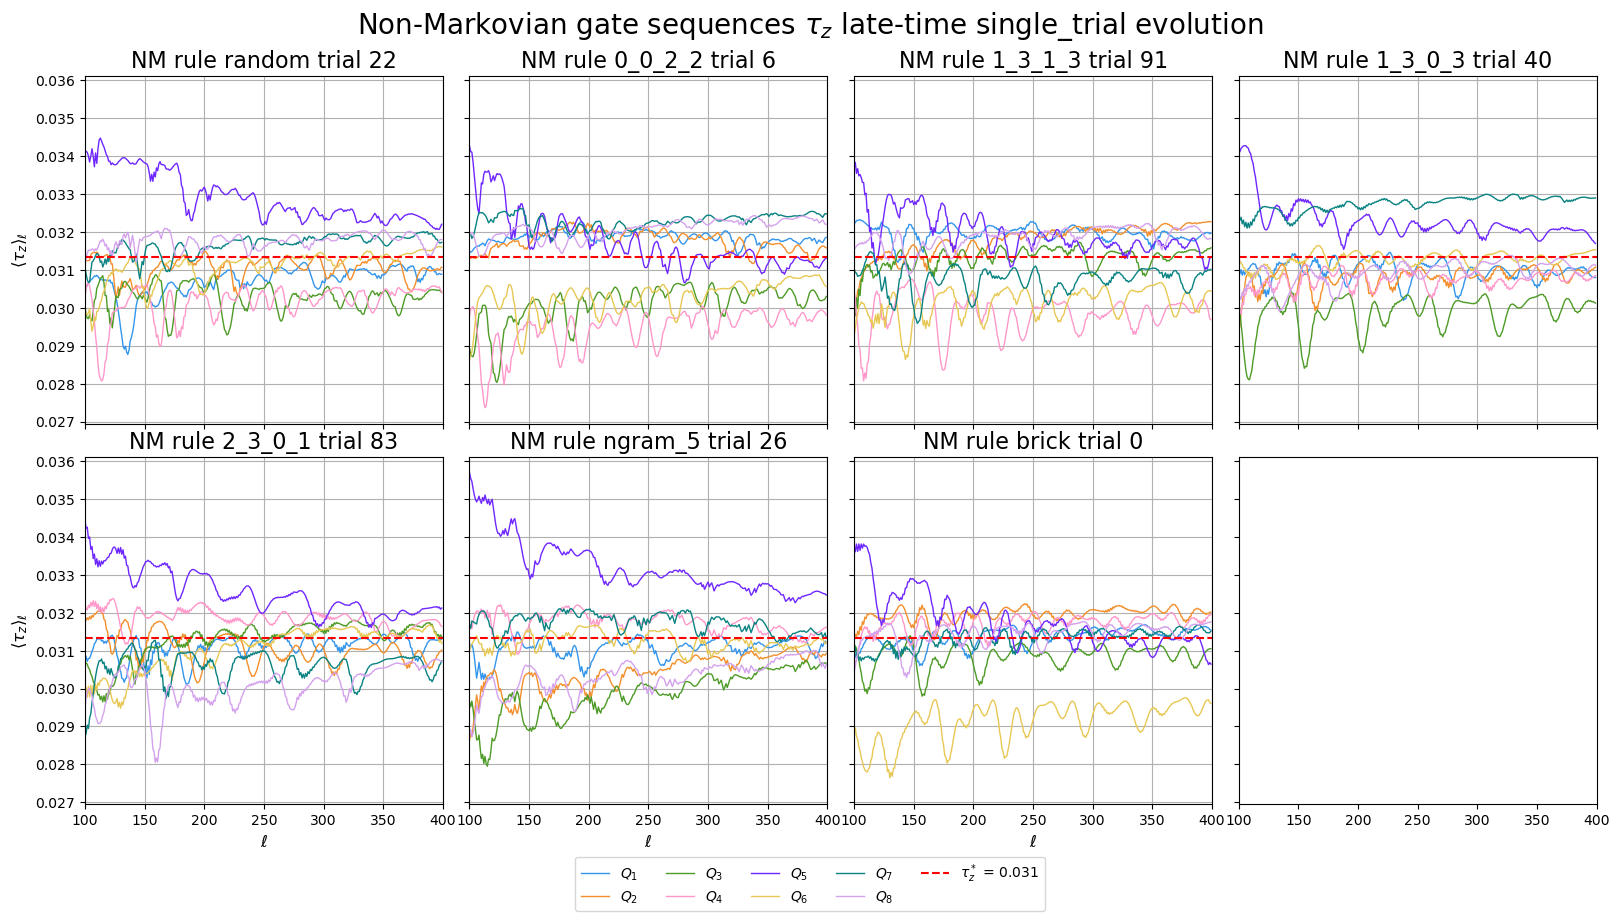

In [315]:
# NEW!!!
# TODO: plot this with different initial
pops_list = list(pops_NM_all.values())
rand_ints = [random.randint(0,num_trials-1) for _ in range(len(pops_list)-1)] + [0]
pops_list = [pop[trial_idx:trial_idx+1,:,:] for pop, trial_idx in zip(pops_list,rand_ints)]

# Call the function with seed=50
plot_connectivity(
    pops_list,
    seed=0,
    ytherm12=np.mean([0.1,0.1,0.1,0.1,0.4,0.1,0.1,0.1]),  # Adjust this value as needed
    population_titles = [f'NM rule {rule_name} trial {trial_idx}' for rule_name, trial_idx in zip(pops_NM_all,rand_ints)],
    start_t = 100,
    stop_t = 400
)
plt.suptitle(r'Non-Markovian gate sequences $\tau_z$ late-time single_trial evolution',fontsize=20, y = 1.05)
plt.savefig(f'{FIGURES_FILEPATH}tz_time_single_trial_comparison_NonMarkovian.pdf', format='pdf', bbox_inches='tight')

# Correlation

In [80]:
def get_2_qbit_dms(data, n_qubits, connectivity,update_rule):
    basis = ket.canonical_basis(2)
    #dimension 0 is each trial
    #dimension 1 is each time step (recall that sampling step is 5 by default)
    #dimension 2 is qubit pair
    #dimension 3 and 4 is the 2 qubit density matrix
    result = []

    def to_tuple(string):
        tuple_elements = string.strip('()').split(',')
        return tuple(int(elem.strip()) for elem in tuple_elements)

    for trial in data[f'{n_qubits} qubits'][f'{connectivity} connectivity']['unitary energy subspace 1']:
        seed = trial.split(' ')[-1]
        dat = dict(data[f'{n_qubits} qubits'][f'{connectivity} connectivity']['unitary energy subspace 1'][f'unitary seed {seed}'][f'ordering seed {update_rule}']['two_qubit_dms'])
        dat = {int(k.split('(')[0]): dat[k] for k in dat}

        dat = np.array([{to_tuple(subkey):DM.DensityMatrix(dat[k][subkey],basis) for subkey in sorted(dat[k])} for k in sorted(dat)])
        result.append(dat)
    return(np.array(result))

def extract_observables(two_qubit_dms, n_qubits):
    """
    Extract single-qubit σz expectation values and two-qubit correlations from density matrices.

    Args:
        two_qubit_dms: Array of shape (n_trials, n_timesteps, n_pairs) containing dictionaries
                       with two-qubit density matrices
        n_qubits: Number of qubits in the system

    Returns:
        sz: Array of shape (n_trials, n_timesteps, n_qubits) with σz expectation values
        corr: Array of shape (n_trials, n_timesteps, n_qubits, n_qubits) with σz-σz correlations
    """
    n_trials = two_qubit_dms.shape[0]
    n_timesteps = two_qubit_dms.shape[1]

    # Pauli Z matrix
    pauli_z = np.array([[1, 0], [0, -1]], dtype=complex)
    pauli_z_tensor = np.kron(pauli_z, pauli_z)

    # Initialize arrays as complex to avoid casting warnings
    sz = np.zeros((n_trials, n_timesteps, n_qubits), dtype=complex)
    corr = np.zeros((n_trials, n_timesteps, n_qubits, n_qubits), dtype=complex)

    # For each trial and timestep
    for trial in range(n_trials):
        for t in range(n_timesteps):
            # Count how many times each qubit appears to average properly
            counts = np.zeros(n_qubits)

            # For each qubit pair
            for pair, dm in two_qubit_dms[trial, t].items():
                i, j = pair

                # Get density matrix as numpy array
                rho = dm.data

                # Calculate local observables
                sz_i = np.trace(rho @ np.kron(pauli_z, np.eye(2, dtype=complex)))
                sz_j = np.trace(rho @ np.kron(np.eye(2, dtype=complex), pauli_z))

                # Calculate correlation
                corr_ij = np.trace(rho @ pauli_z_tensor) - sz_i * sz_j

                # Update counts
                counts[i] += 1
                counts[j] += 1

                # Update expectation values (will average later)
                sz[trial, t, i] += sz_i
                sz[trial, t, j] += sz_j

                # Store correlation
                corr[trial, t, i, j] = corr_ij
                corr[trial, t, j, i] = corr_ij

            # Average the expectation values
            for i in range(n_qubits):
                if counts[i] > 0:
                    sz[trial, t, i] /= counts[i]

    # Take real parts at the end - for Hermitian observables like Pauli-Z
    # the expectation values should be real, with any imaginary component
    # coming from numerical imprecision
    return sz.real, corr.real

    return sz, corr

In [ ]:
%%script echo skipping
# comment out this line above to run this cell

# each rule's twoQdms takes ~6min
twoQdms_all = {}
for rule_name in newdata_all:
    if rule_name == 'random': 
        twoQdms_all[rule_name] = get_2_qbit_dms(newdata_all[rule_name],
                                            n_qubits,"c2_2local", "random")
    else: 
        twoQdms_all[rule_name] = get_2_qbit_dms(newdata_all[rule_name],
                                                n_qubits,"c2_2local", "NonMarkovian")

In [ ]:
%%script echo skipping
# comment out this line above to run this cell

# this takes about ~14min
np.save('./NM_twoQdms_all.npy', twoQdms_all) 

In [58]:
# %%script echo skipping
# comment out this line above to run this cell

# this cell takes ~
corrs_NM_all = {}
for rule_name in twoQdms_all: 
    corrs_NM_all[rule_name] = extract_observables(twoQdms_all[rule_name], 
                                                n_qubits)

# save dictionaries as files
np.save('./NM_corrs_all.npy', corrs_NM_all) 

In [26]:
twoQdms_all = np.load('./NM_twoQdms_all.npy',allow_pickle='TRUE').item()
corrs_NM_all = np.load('./NM_corrs_all.npy',allow_pickle='TRUE').item()

In [74]:
def plot_multiple_correlation_distributions(correlation_datasets, labels, colors, bins=30, nrows=1):
    """
    Plot correlation magnitude distributions for multiple datasets in a single row
    with square-like aspect ratio for each plot.

    Args:
        correlation_datasets: List of correlation arrays or tuples
        labels: List of labels for each dataset
        colors: List of colors for each dataset
        bins: Number of histogram bins (default: 30)
        nrows: number of rows to plot subplots on

    Returns:
        fig: The figure object
        stats_dict: Dictionary with correlation statistics for each dataset
    """
    # Calculate figure size based on number of datasets to maintain square plots
    n_datasets = len(correlation_datasets)
    ncols = int(np.ceil(n_datasets/nrows))

    # Create figure
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4),
                            sharey=True,sharex=True)

    # Handle case of single dataset
    if n_datasets == 1:
        axes = [axes]

    # Container for statistics
    stats_dict = {}

    # Process each dataset
    for i, corr_data in enumerate(correlation_datasets):
        # Handle case where input might be a tuple
        if isinstance(corr_data, tuple) and len(corr_data) >= 2:
            corr = corr_data[1]  # Extract correlations
        else:
            corr = corr_data

        # Get dimensions
        if len(corr.shape) == 4:
            n_trials, n_timesteps, n_qubits, _ = corr.shape
        else:
            # Handle case where there might not be multiple trials
            n_timesteps, n_qubits, _ = corr.shape
            n_trials = 1
            corr = corr.reshape(1, n_timesteps, n_qubits, n_qubits)

        # Calculate correlation magnitudes (absolute values)
        corr_abs = np.abs(corr)

        # Average over trials
        avg_corr_abs = np.mean(corr_abs, axis=0)

        # Create mask to exclude self-correlations (diagonal elements)
        mask = ~np.eye(n_qubits, dtype=bool)
        mask_3d = np.broadcast_to(mask, (n_timesteps, n_qubits, n_qubits))

        # Extract off-diagonal elements for each time step
        off_diag_values = []
        for t in range(n_timesteps):
            off_diag_values.append(avg_corr_abs[t][mask])

        # Calculate statistics
        means = np.array([np.mean(vals) for vals in off_diag_values])
        medians = np.array([np.median(vals) for vals in off_diag_values])
        max_vals = np.array([np.max(vals) for vals in off_diag_values])
        percentile_75 = np.array([np.percentile(vals, 75) for vals in off_diag_values])
        percentile_90 = np.array([np.percentile(vals, 90) for vals in off_diag_values])

        # Calculate overall statistics
        overall_stats = {
            'mean': np.mean(means),
            'median': np.median(medians),
            'max': np.max(max_vals),
            'p75': np.mean(percentile_75),
            'p90': np.mean(percentile_90)
        }

        # Create recommended thresholds
        recommended_thresholds = [
            overall_stats['p75'],  # Conservative
            overall_stats['mean'],        # Moderate
            overall_stats['p90']         # Stringent
        ]

        # Round thresholds for clarity
        recommended_thresholds = [round(t, 3) for t in recommended_thresholds]

        # Store statistics for this dataset
        stats_dict[labels[i]] = {
            'overall': overall_stats,
            'by_time': {
                'mean': means,
                'median': medians,
                'max': max_vals,
                'p75': percentile_75,
                'p90': percentile_90
            },
            'recommended_thresholds': recommended_thresholds
        }

        # Flatten all off-diagonal correlations from all time steps for plotting
        all_corrs = np.concatenate(off_diag_values)

        ##################### plotting ###########
        row = i // ncols
        col = i % ncols
        # Plot histogram with KDE
        sns.histplot(all_corrs, bins=bins, kde=True, 
                    color=colors[i], alpha=0.25, edgecolor=None,
                    ax=axes[row][col])

        # Add vertical lines for recommended thresholds
        recommended_thresholds_names = ['P75','Mean','P90']
        for j, threshold in enumerate(recommended_thresholds):
            linestyle = ['--', '-', '-.'][j % 3]
            axes[row][col].axvline(x=threshold, 
                            color="#17114B", linestyle=linestyle, lw=1.0,
                            alpha=0.7, label=recommended_thresholds_names[j])

        # Set labels and title
        axes[row][col].set_xlabel('Correlation Magnitude')

        if i == 0:  # Only add y-label to the first plot
            axes[row][col].set_ylabel('Frequency')
        else:
            axes[row][col].set_ylabel('')  # Remove y-labels from other plots

        # add legend only to last plot
        if i == n_datasets - 1:
            axes[row][col].legend(fontsize=10)

        # set title for each plot
        axes[row][col].set_title(f'{labels[i]}')

        # set square ratio for each plot 
        # axes[i].set_box_aspect(1)

        # Add stats below the plot
        stats_text = (f"Mean: {overall_stats['mean']:.3f} \n "
                    f"Median: {overall_stats['median']:.3f} \n "
                    f"Max: {overall_stats['max']:.3f} \n")

        thresholds_text = (f"Thresholds:\n {recommended_thresholds[0]:.3f}\n "
                        f"{recommended_thresholds[1]:.3f}\n "
                        f"{recommended_thresholds[2]:.3f}")

        # axes[row][col].annotate(stats_text, xy=(0.5, -0.10), xycoords='axes fraction',
        #                 ha='center', va='center', fontsize=9)

        # axes[row][col].annotate(thresholds_text, xy=(0.5, -0.15), xycoords='axes fraction',
        #                 ha='center', va='center', fontsize=9)

        # these are matplotlib.patch.Patch properties
        props = dict(boxstyle='round', facecolor='white', edgecolor='grey',alpha=0.5)

        # place a text box in upper left in axes coords
        axes[row][col].text(0.95, 0.95, stats_text + thresholds_text, transform=axes[row][col].transAxes, fontsize=9,
                verticalalignment='top',horizontalalignment='right',bbox=props)

    plt.tight_layout(pad=0.0)

    return fig, stats_dict

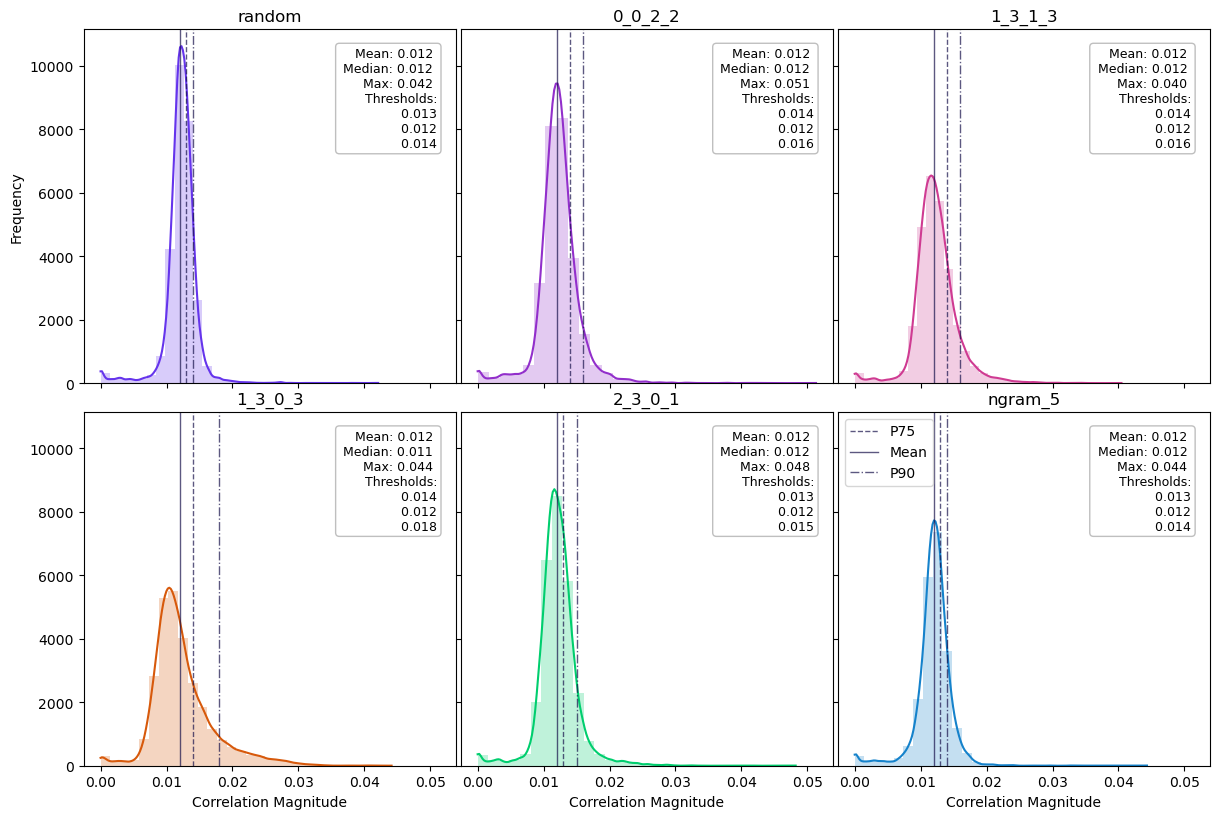

In [75]:
corrs_NM_all_datas = list(corrs_NM_all.values())
corss_NM_labels = list(corrs_NM_all.keys())

# Define colors for each rule
colors = ["#6534EC",
        "#922FCB",
        "#CF3B92",
        "#D7590B",
        "#00CE6E",
        "#1582CB"]

# Plot all data in a single grid
fig, all_stats = plot_multiple_correlation_distributions(corrs_NM_all_datas, labels = corss_NM_labels, colors=colors,nrows=2)

# Save the figure
plt.savefig(f'{FIGURES_FILEPATH}all_correlation_distributions_grid_NM.png', dpi=300 ,bbox_inches='tight')
plt.show()

# Relative entropy + trace distance

Relative entropy: 
$$
\mathcal{D} (\{\rho_q\}, \bar{\rho} )
    = 
    \sum_{q=1}^N Tr [\rho_q (\log{\rho_1} - \log{\bar{\rho}})]
$$

Trace distance: 
$$
Tr (\rho^{(N)}, \bar{\rho}^{(N)}) 
    = 
    \frac{1}{2} 
    \sum_{q=1}^N |p_q - \bar{p}|
$$

In [ ]:
def get_thermal_pop(E, N):
    ''' 
    Gives thermal population value based on energy and number of qubits.

    Parameters
    ---------- 
    E : energy, E = sum of all qubits' z_q = sum of all qubits' (1 - 2 p_q)
    N : int, number of qubits

    Return
    ------
    thermal population value ($\bar{p}$)
    '''
    return (1. - E / N) / 2.0 

def single_qubit_pop_to_rho(p):
    '''
    Parameters
    ----------
    p : population

    Return
    ------
    Density matrix corresponding to p
    '''
    return np.array([[1-p, 0],[0, p]])

# define initial populations 
init_pops = [0.1,0.1,0.1,0.1,0.4,0.1,0.1,0.1]

# get E -- energy/excitation
E = np.sum([1. - 2 * p for p in init_pops])

# calculate thermal population
thermal_pop = get_thermal_pop(E, n_qubits)

# calculate rho corresponding to thermal population
thermal_rho = single_qubit_pop_to_rho(thermal_pop)

array([[0.8625, 0.    ],
       [0.    , 0.1375]])

In [187]:
np.log(thermal_rho)

/var/folders/xr/spzdt0tj3zj_ns139lpchs1w0000gn/T/ipykernel_77930/165662814.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(thermal_rho)


array([[-0.14792013,        -inf],
       [       -inf, -1.98413136]])

In [190]:
expm([[0.8625, 0.    ],
       [0.    , 0.1375]])

array([[2.36907599, 0.        ],
       [0.        , 1.14740171]])

In [156]:
def get_single_qubit_relative_entropy(pop_q, log_thermal_rho):
    '''
    Calculate relative entropy for a single population. 

    Parameters
    ----------
    pop_q : value of a population 
    log_thermal_rho : 2x2 matrix, matrix natural log of the thermal density matrix, 
        corresponding to the thermal p ($\bar{p}$). 
    '''
    rho_q = single_qubit_pop_to_rho(pop_q)
    return np.trace(rho_q @ (logm(rho_q) - log_thermal_rho) )

def get_all_qubit_relative_entropy(pops, thermal_rho):
    ''' 
    Calculate relative entropy values for an entire pops matrix.

    Parameters
    ----------
    pops : populations, with dimension (# trials, # time steps, # qubits) 
    thermal_rho : 2x2 matrix of thermal density matrix, corresponding to the 
        thermal p ($\bar{p}$). 
    '''
    log_thermal_rho = logm(thermal_rho)
    
    rel_entropy_mat = np.zeros((pops.shape))

    for i,trial in enumerate(pops):
        for j, time_step in enumerate(trial):
            for k, p_q in enumerate(time_step): 
                rel_entropy_mat[i][j][k] = get_single_qubit_relative_entropy(p_q, log_thermal_rho)

    return rel_entropy_mat

def get_trace_distance(pops, p_therm): 
    ''' 
    Calculate trace distance, with respect to p_therm, for given populations (pops),
    regardless of the shape of pops. 
    '''
    return np.abs(pops - p_therm)/2.0

In [142]:
%%time
# check that these functions are what we expect for the thermal situation
assert get_single_qubit_relative_entropy(thermal_pop, logm(thermal_rho)) == 0

pops_thermal = np.full((1,100,8),thermal_pop)
assert (get_all_qubit_relative_entropy(pops_thermal, thermal_rho) == 0).all()

assert (get_trace_distance(pops_thermal, thermal_pop) == 0).all()

CPU times: user 665 ms, sys: 10.6 ms, total: 676 ms
Wall time: 341 ms


In [166]:
%%time

# rel_entropy_dict = np.load('./rel_entropy_dict.npy',allow_pickle='TRUE').item()
# trace_dist_dict = np.load('./trace_dist_dict.npy',allow_pickle='TRUE').item()

rule_names = ['0_0_2_2','1_3_1_3','2_3_0_1', 'ngram_5']

for rule_name in rule_names: 
    # calculate relative entropy + trace distance for just one rule
    rel_entropy_dict[rule_name] = get_all_qubit_relative_entropy(pops_NM_all[rule_name], thermal_rho)
    trace_dist_dict[rule_name] = get_trace_distance(pops_NM_all[rule_name], thermal_pop)

np.save('./rel_entropy_dict.npy',rel_entropy_dict)
np.save('./trace_dist_dict.npy',trace_dist_dict)
# TODO: when I have time, run this for all rules...

CPU times: user 20min 34s, sys: 6.91 s, total: 20min 41s
Wall time: 10min 33s


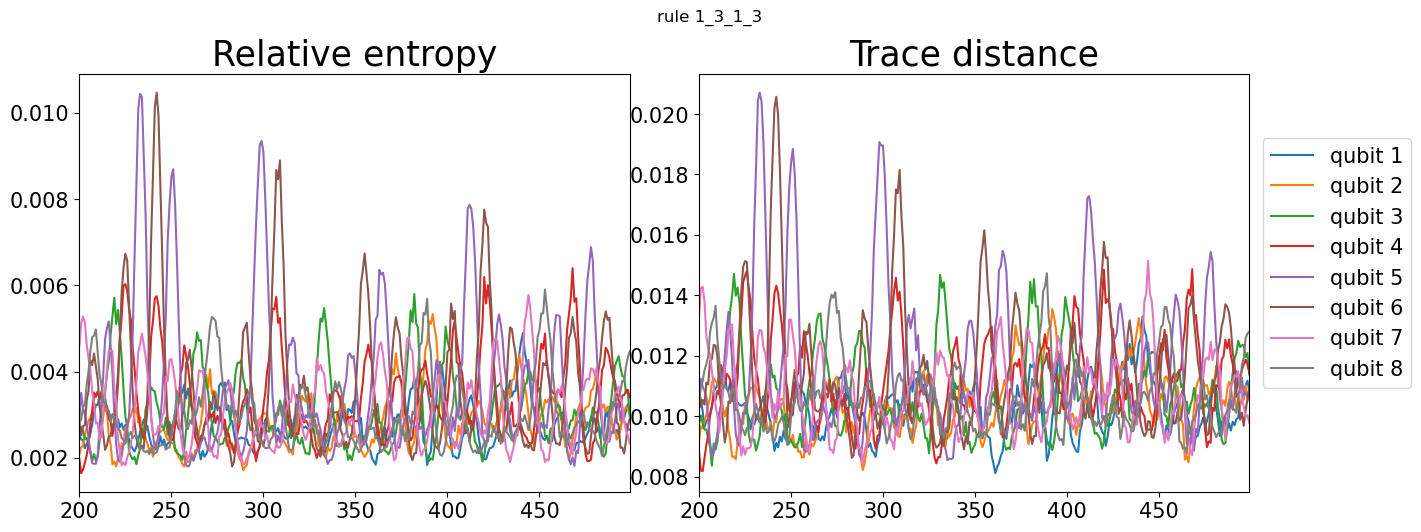

In [185]:
# plot evolution in relative entropy + trace distance by qubit
fig, axs = plt.subplots(1,2, figsize=(2*7,5))

rule_name = '1_3_1_3'

steps_range = (200,500)

rel_entropy_trial_avg = np.mean(rel_entropy_dict[rule_name], axis=0)[steps_range[0]:steps_range[1],:].T
trace_dist_trial_avg = np.mean(trace_dist_dict[rule_name], axis=0)[steps_range[0]:steps_range[1],:].T

t_steps = np.arange(steps_range[0],steps_range[1],1)

for i, (rel_entropy_line, trace_dist_line) in enumerate(zip(rel_entropy_trial_avg, trace_dist_trial_avg)):
    axs[0].plot(t_steps,rel_entropy_line,
                label=f'qubit {i+1}')
    axs[1].plot(t_steps, trace_dist_line,
                label=f'qubit {i+1}')

axs[0].set_title('Relative entropy',fontsize=25)
axs[1].set_title('Trace distance',fontsize=25)

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.set_xlim(steps_range[0],steps_range[1]-1)
    # ax.grid(axis='y')
plt.legend(loc=(1.025, 0.25), fontsize=15)

fig.suptitle(f'rule {rule_name}',y=1.025)
plt.tight_layout(pad=0.0)

# TODO: write equation for both on y-axis

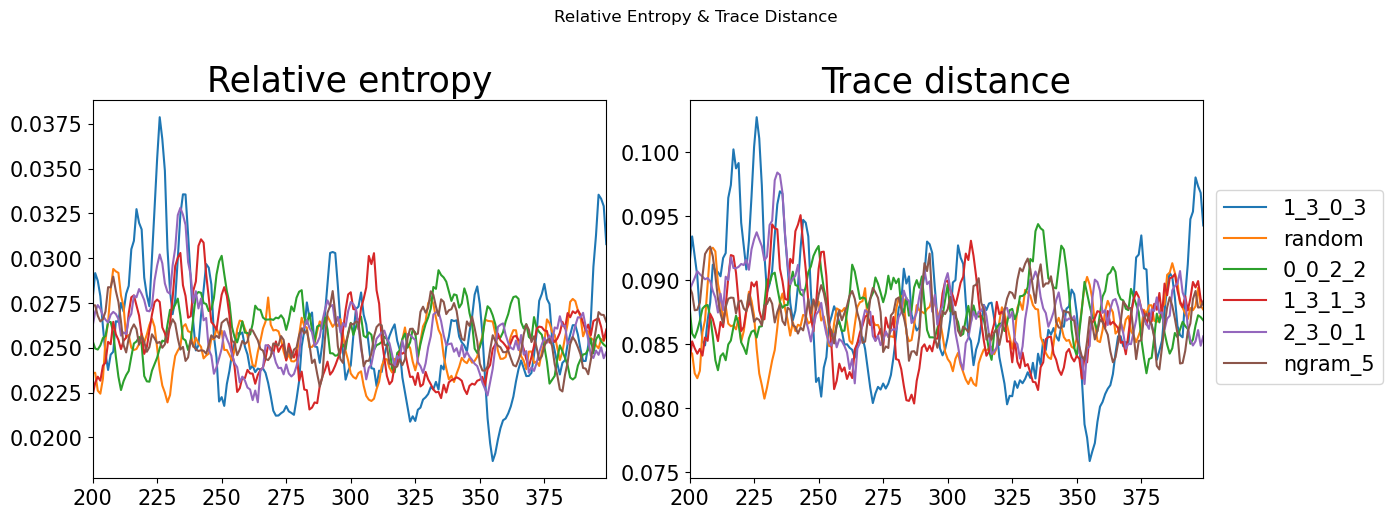

In [186]:
# plot evolution in relative entropy + trace distance, summing over qubits, for multiple
fig, axs = plt.subplots(1,2, figsize=(2*7,5))

steps_range = (200,400)

t_steps = np.arange(steps_range[0],steps_range[1],1)

for rule_name in rel_entropy_dict.keys():
    rel_entropy = rel_entropy_dict[rule_name][:,steps_range[0]:steps_range[1],:]
    trace_dist = trace_dist_dict[rule_name][:,steps_range[0]:steps_range[1],:]

    rel_entropy_trial_ens_avg = np.sum(np.mean(rel_entropy, axis=0),axis=1)
    trace_dist_trial_ens_avg = np.sum(np.mean(trace_dist, axis=0),axis=1)

    axs[0].plot(t_steps, rel_entropy_trial_ens_avg)
    axs[1].plot(t_steps, trace_dist_trial_ens_avg, label=rule_name)

axs[0].set_title('Relative entropy',fontsize=25)
axs[1].set_title('Trace distance',fontsize=25)

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.set_xlim(steps_range[0],steps_range[1]-1)
    # ax.grid(axis='y')

plt.legend(loc=(1.025, 0.25), fontsize=15)

fig.suptitle(f'Relative Entropy & Trace Distance',y=1.025)
plt.tight_layout(pad=1.0)

# TODO: write equation for both on y-axis

# Mutual information networks

In [53]:
def mutual_info_dicts(twoQdms, trial_index):
    mutual_info_list = []
    for time_step in twoQdms[trial_index]:
        mutual_info_dict = {}
        mutual_info = measure.mutual_information_of_every_pair_dict(time_step)
        # Filter out values below the precision threshold
        filtered_mutual_info = {k: v if v >= 1e-6 else 0 for k, v in mutual_info.items()}
        # Update the mutual_info_dict with the filtered mutual info for the current time step
        mutual_info_dict.update(filtered_mutual_info)
        # Append the mutual_info_dict to the list
        mutual_info_list.append(mutual_info_dict)
    return mutual_info_list

# Call the two_point_dict function for each trial index
# Get the list of dictionaries containing two point values for each time step
def create_adjacency_matrix_two_dim(two_point_dict, num_nodes):
    adjacency_matrix = [[0] * num_nodes for _ in range(num_nodes)]
    for (node1, node2), two_point_value in two_point_dict.items():
        adjacency_matrix[node1][node2] = two_point_value
        adjacency_matrix[node2][node1] = two_point_value  # Assuming undirected graph
    return adjacency_matrix

def adjacency_matrices_list_two_dim(twoQdms, trial_index, num_nodes, two_point_dicts):
    # Get the list of dictionaries containing mutual information values for each time step
    two_point_dicts_list = two_point_dicts(twoQdms, trial_index)
    # Create adjacency matrices for each time step
    adjacency_matrices = []
    for two_point_dict in two_point_dicts_list:
        adj_matrix = create_adjacency_matrix_two_dim(two_point_dict, num_nodes)
        adjacency_matrices.append(adj_matrix)
    return adjacency_matrices

def generate_all_adjacency_matrices(twoQdms, num_seeds, num_qubits, mutual_info_dicts):
    # Initialize an empty list to store the adjacency matrices for each trial
    all_trials_adjacency_matrices = []

    # Loop over each seed from 0 to num_seeds-1
    for seed in range(num_seeds):
        # Generate an empty list to store adjacency matrices for this trial
        trial_matrices = []

        # Generate the adjacency matrix for the given seed
        adj_matrix = adjacency_matrices_list_two_dim(twoQdms, seed, num_qubits, mutual_info_dicts)

        # Append each generated adjacency matrix to the trial-specific list
        trial_matrices.append(adj_matrix)

        # Append the list of matrices for this trial to the overall list
        all_trials_adjacency_matrices.append(trial_matrices)

    # Convert to a NumPy array if needed
    all_trials_adjacency_matrices_array = np.array(all_trials_adjacency_matrices)

    return all_trials_adjacency_matrices_array

In [51]:
def disparity_per_node(adjacency_matrix):
    """Calculate disparity measure for each node in the graph using the provided formula"""
    adj_mat = np.array(adjacency_matrix)
    n_nodes = adj_mat.shape[0]
    node_disparity = {}

    for i in range(n_nodes):
        row_sum_squared = np.sum(adj_mat[i])**2
        row_sum_of_squared_elements = np.sum(adj_mat[i]**2)

        # Check for zero division
        if row_sum_squared == 0:
            node_disparity[i] = 0
        else:
            node_disparity[i] = row_sum_of_squared_elements / row_sum_squared

    return node_disparity

def clustering_coeff(adjacency_matrix_list):
    """Calculate global clustering coefficient for a list of adjacency matrices"""
    C_list = []
    for adj_mat in adjacency_matrix_list:
        adj_mat = np.array(adj_mat)
        M_sq = adj_mat @ adj_mat
        sum_of_M_sq = np.sum(M_sq)
        M_cube = adj_mat @ adj_mat @ adj_mat
        M_cube_trace = np.trace(M_cube)
        if sum_of_M_sq == 0:
            C_list.append(0)
        else:
            C_list.append(M_cube_trace / sum_of_M_sq)
    return np.array(C_list)

def disparity_function(adjacency_matrix_list, N):
    """Calculate global disparity for a list of adjacency matrices"""
    D_list = []
    for adj_mat in adjacency_matrix_list:
        M_row_sum_squared = np.sum(adj_mat, axis=1)**2
        M_row_sum_of_squared_elements = np.sum(adj_mat**2, axis=1)
        # Check for zero division before performing division
        Di = np.where(M_row_sum_squared != 0, M_row_sum_of_squared_elements / M_row_sum_squared, 0)
        D_list.append(np.sum(Di) / N)
    return np.array(D_list)

def clustering_per_node(adjacency_matrix):
    """Calculate clustering coefficient for each node using the provided formula"""
    adj_mat = np.array(adjacency_matrix)
    n_nodes = adj_mat.shape[0]
    node_clustering = {}

    # Create a networkx graph to use for node-specific calculations
    G = nx.from_numpy_array(adj_mat)

    for i in range(n_nodes):
        neighbors = list(G.neighbors(i))
        if len(neighbors) <= 1:
            node_clustering[i] = 0.0
            continue

        triangles = 0
        possible_triangles = len(neighbors) * (len(neighbors) - 1) / 2

        if possible_triangles == 0:
            node_clustering[i] = 0.0
            continue

        # Count triangles for this node
        for j in neighbors:
            for k in neighbors:
                if j < k and G.has_edge(j, k):
                    triangles += 1

        node_clustering[i] = triangles / possible_triangles

    return node_clustering

def visualize_multiple_networks(datasets, dataset_names=None):
    """
    Visualize multiple temporal networks using representative network method

    Parameters:
    datasets: list of lists of adjacency matrices, each representing a temporal network
    dataset_names: optional list of names for the datasets

    Returns:
    Dictionary with metrics for each dataset and method
    """
    if dataset_names is None:
        dataset_names = [f"R {i+1}" for i in range(len(datasets))]

    n_datasets = len(datasets)

    # First pass: calculate all disparity values to determine global min/max
    all_node_disparity = []
    rep_matrices = []

    for dataset in datasets:
        # Calculate representative matrix
        n_timepoints = len(dataset)
        late_period = int(n_timepoints * 0.25)
        rep_matrix = np.mean(dataset[-late_period:], axis=0)
        rep_matrices.append(rep_matrix)

        # Calculate disparity for each node
        node_disparity_values = list(disparity_per_node(rep_matrix).values())
        all_node_disparity.extend(node_disparity_values)

    # Determine global min and max disparity values
    global_min_disparity = min(all_node_disparity)
    global_max_disparity = max(all_node_disparity)

    # Create a figure with 1 row and n_datasets columns
    fig = plt.figure(figsize=(5*n_datasets, 6))
    gs = GridSpec(1, n_datasets, figure=fig)

    # Store metrics for all datasets
    all_metrics = {name: {} for name in dataset_names}

    # For each dataset, create a representative network
    for col, (dataset, name, rep_matrix) in enumerate(zip(datasets, dataset_names, rep_matrices)):
        # Create subplot
        ax = fig.add_subplot(gs[0, col])

        # Generate representative network with global disparity range
        rep_matrix, G_rep, metrics = create_representative_network(
            dataset,
            rep_matrix=rep_matrix,
            ax=ax,
            title=f"{name}\n",
            global_min_disparity=global_min_disparity,
            global_max_disparity=global_max_disparity
        )

        # Store metrics
        all_metrics[name] = metrics

    # Add a single colorbar for the entire figure
    cax = fig.add_axes([0.92, 0.3, 0.02, 0.4])  # [left, bottom, width, height]
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis,
                             norm=plt.Normalize(vmin=global_min_disparity,
                                              vmax=global_max_disparity))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label('Disparity',fontsize=16)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85, bottom=0.05, right=0.9, hspace=0.3)
    #plt.savefig('MI_12_Q_therm_all_rules_spring_network_c4.png', bbox_inches='tight', pad_inches=0.5, dpi=300)
    plt.show()

    # Print summary metrics
    #print("\nSummary Metrics:")
    #for name in dataset_names:
    #    print(f"\n{name}:")
    #    metrics = all_metrics[name]
    #    for key, value in metrics.items():
    #        print(f"    - {key}: {value}")

    return all_metrics

def create_representative_network(time_matrices, ax=None, title=None, rep_matrix=None,
                            global_min_disparity=None, global_max_disparity=None):
    """
    Create and visualize a representative network from time-evolving data

    Parameters:
    time_matrices: list of adjacency matrices over time
    ax: matplotlib axis for plotting (if None, creates a new figure)
    title: title for the plot
    rep_matrix: pre-computed representative matrix (if None, it will be calculated)
    global_min_disparity: minimum disparity value for color normalization
    global_max_disparity: maximum disparity value for color normalization

    Returns:
    Representative adjacency matrix, networkx graph, and metrics
    """
    n_timepoints = len(time_matrices)
    n_nodes = time_matrices[0].shape[0]

    # Calculate representative matrix if not provided
    if rep_matrix is None:
        # Calculate representative matrix - using last 20% of time points
        late_period = int(n_timepoints * 0.2)
        rep_matrix = np.mean(time_matrices[-late_period:], axis=0)

    # Create a new figure if needed
    if ax is None:
        plt.figure(figsize=(10, 8))
        ax = plt.gca()

    # Create networkx graph
    G_rep = nx.from_numpy_array(rep_matrix)

    # Edge weights for thickness
    edges = G_rep.edges()
    edge_weights = nx.get_edge_attributes(G_rep, 'weight')
    if edge_weights:
        max_weight = max(edge_weights.values()) if edge_weights else 1.0
        weights = [G_rep[u][v]['weight'] * 5.0 / max_weight for u, v in edges]
    else:
        weights = [1.0] * len(edges)

    # Node sizes (fixed)
    node_sizes = [400] * n_nodes

    # Calculate clustering coefficient for each node using provided formula
    node_clustering = list(clustering_per_node(rep_matrix).values())

    # Calculate disparity for each node using provided formula
    node_disparity = list(disparity_per_node(rep_matrix).values())

    # Position nodes
    pos = nx.spring_layout(G_rep, weight='weight', k=0.3, iterations=300, seed=42)

    # Draw the network with disparity coloring
    # Use global min/max disparity values if provided, otherwise use local values
    if global_min_disparity is not None and global_max_disparity is not None:
        vmin, vmax = global_min_disparity, global_max_disparity
    else:
        vmin, vmax = min(node_disparity), max(node_disparity)

    nodes = nx.draw_networkx_nodes(G_rep, pos,
                                  node_size=node_sizes,
                                  node_color=node_disparity,
                                  cmap=plt.cm.viridis,
                                  vmin=vmin,
                                  vmax=vmax,
                                  alpha=0.8,
                                  ax=ax)

    # Individual colorbar is skipped - we'll add a global one later

    # Draw edges with varying thickness
    edges = nx.draw_networkx_edges(G_rep, pos,
                                  width=weights,
                                  edge_color='gray',
                                  alpha=1,
                                  ax=ax)

    # Draw labels for smaller networks
    if n_nodes <= 10:
        nx.draw_networkx_labels(G_rep, pos, font_size=8, ax=ax)

    # Calculate key metrics for the representative network
    metrics = {}

    # Basic network metrics
    metrics['density'] = nx.density(G_rep)
    metrics['num_edges'] = G_rep.number_of_edges()

    # Global clustering using the provided formula
    metrics['global_clustering'] = clustering_coeff([rep_matrix])[0]

    # Global disparity using the provided formula
    n_nodes = rep_matrix.shape[0]
    metrics['global_disparity'] = disparity_function([rep_matrix], n_nodes)[0]

    # Node-level metrics
    metrics['mean_clustering'] = np.mean(node_clustering)
    metrics['std_clustering'] = np.std(node_clustering)

    # Disparity metrics
    metrics['mean_disparity'] = np.mean(node_disparity)
    metrics['std_disparity'] = np.std(node_disparity)

    try:
        if nx.is_connected(G_rep):
            metrics['avg_path_length'] = nx.average_shortest_path_length(G_rep, weight='weight')
        else:
            # Calculate for largest connected component
            gcc = max(nx.connected_components(G_rep), key=len)
            metrics['avg_path_length'] = nx.average_shortest_path_length(
                G_rep.subgraph(gcc), weight='weight')
    except:
        metrics['avg_path_length'] = 'N/A'

    # Display mean and std of clustering and disparity under the graph
    if title:
        ax.set_title(title, fontsize=20)

    # Add text with metrics below the graph
    plt.text(0.5, -0.1,
             f"Global Clustering: {metrics['global_clustering']:.5e}\n"
             f"Global Disparity: {metrics['global_disparity']:.5e}\n"
             #f"Mean Clustering: {metrics['mean_clustering']:.6e} (±{metrics['std_clustering']:.6e})\n"
             f"Mean Disparity: {metrics['mean_disparity']:.5e} (±{metrics['std_disparity']:.5e})",
             horizontalalignment='center',
             verticalalignment='center',
             transform=ax.transAxes,
             fontsize=13,
             bbox=dict(facecolor='white', alpha=0.9))

    ax.axis('off')


    return rep_matrix, G_rep, metrics

In [54]:
num_seeds = 5

MI_adj = {}
for rule_name in twoQdms_all:
    MI_adj[rule_name] = generate_all_adjacency_matrices(twoQdms_all[rule_name], 
                                                        num_seeds, n_qubits, mutual_info_dicts)

/var/folders/xr/spzdt0tj3zj_ns139lpchs1w0000gn/T/ipykernel_39061/2279383268.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


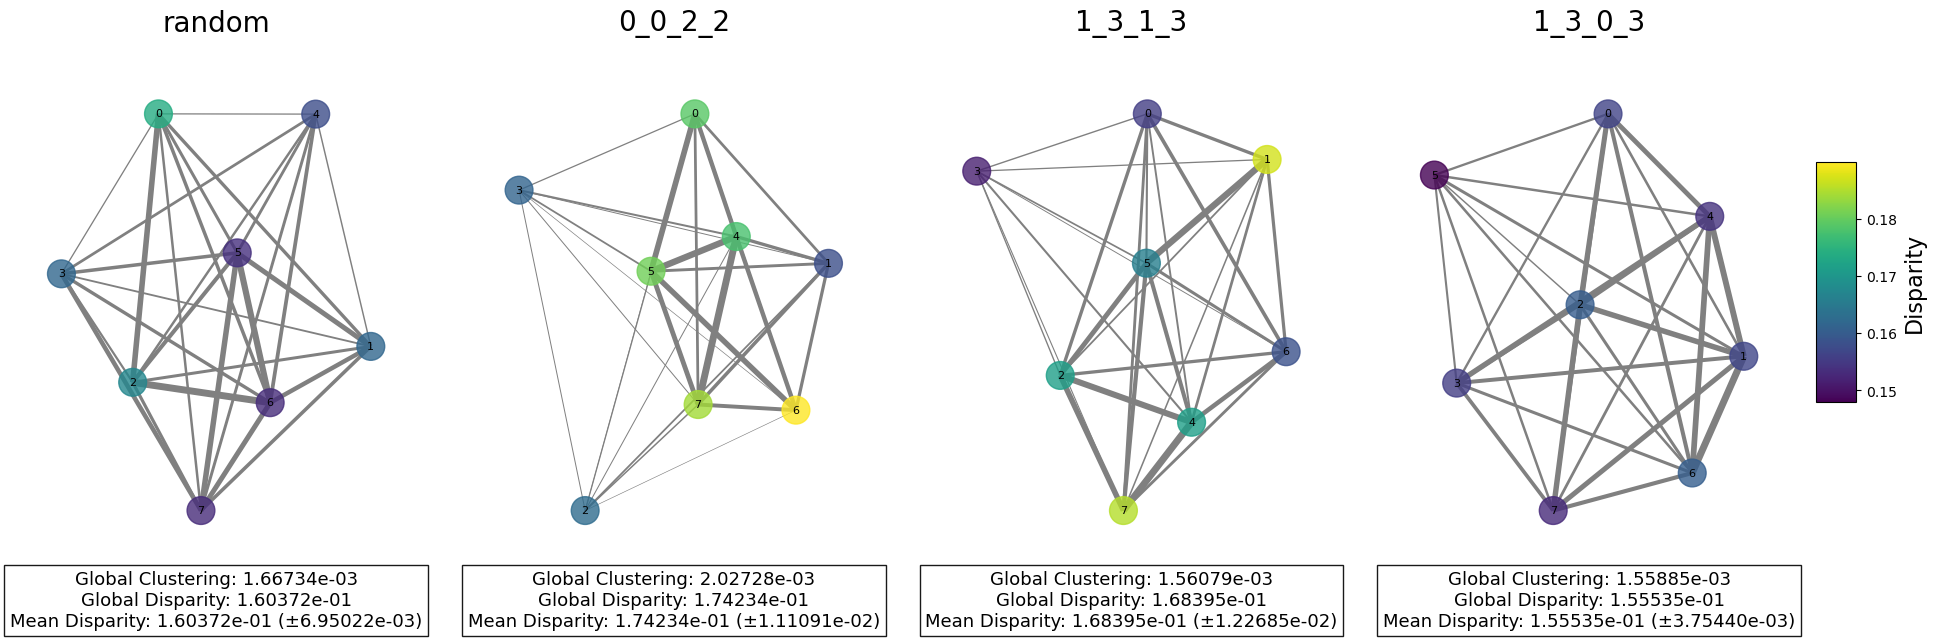

In [68]:
# visualize network for given set of start, end times 
network_names = list(twoQdms_all.keys())[:4]
m_list=[random.randint(0,num_seeds-1) for _ in network_names]
start = 300
end=500

network_list = [MI_adj[rule_name][m][0][start:end] for m,rule_name in zip(m_list, network_names)]

# TODO: what do the seeds mean? just trial #? 

all_metrics = visualize_multiple_networks(network_list, dataset_names=network_names)

# Emergent graph

In [51]:
def adj_matrix_c2_2local_gate_probs(gate_probs,n_qubits): 
    adj_matrix = np.zeros((n_qubits,n_qubits))

    gate_a = [[i,i+1] for i in range(0,n_qubits,2)]
    gate_b = [[i,i+1] for i in range(1,n_qubits-1,2)] + [[n_qubits-1,0]]

    for (x,y) in gate_a:
        adj_matrix[x][y] = gate_probs[0]
        adj_matrix[y][x] = gate_probs[0]
    
    for (x,y) in gate_b:
        adj_matrix[x][y] = gate_probs[1]
        adj_matrix[y][x] = gate_probs[1]
    return adj_matrix

def emergent_network_plot(adj_matrix, ax, title, 
                        cmap = mpl.colormaps['viridis']):
        """
        Visualizes a network based on the provided adjacency matrix.
        """
        # Create graph
        G = nx.from_numpy_array(adj_matrix)

        # create circular position
        pos = nx.circular_layout(G)

        # Normalize the weights for colormap
        weights = np.array([G[u][v]['weight'] for u, v in G.edges()])
        # norm = plt.Normalize(vmin=np.min(adj_matrix[np.nonzero(adj_matrix)]), vmax=np.max(adj_matrix))
        norm = plt.Normalize(vmin=0.3, vmax=0.7)

        # Map edge weights to colors using the given colormap
        edge_colors = [cmap(norm(w)) for w in weights]

        # Scale edge thickness according to the weight (here using width factor for better visibility)
        # min_width = 3.0 # Minimum edge width (for visualization)
        # max_width = 5.0 # Maximum edge width (for visualization)
        # edge_widths = min_width + (weights - np.min(weights)) / (np.max(weights) - np.min(weights)) * (max_width - min_width)

        # Draw graph with node labels 
        # nx.draw(G, pos, with_labels=True, node_color='grey', node_size=500,
        #         edge_color=edge_colors, width=3, ax=ax)
        nx.draw(G, pos, with_labels=True, node_color="#CCCCCC", node_size=500,
                edge_color=edge_colors, 
                # width=edge_widths, 
                width=14,
                ax=ax)
        
        # Add a color bar to show the weight scale
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        # sm.set_array([])
        # plt.colorbar(sm, ax=ax, label="Edge weight")

        # Add a title to each subplot
        ax.set_title(title,fontsize=25, y=0.975)
        return sm

0.5040836653386453 0.49591633466135465
0.5742430278884464 0.4257569721115536
0.684368686868687 0.315631313131313


/var/folders/xr/spzdt0tj3zj_ns139lpchs1w0000gn/T/ipykernel_77930/3658524541.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.0)


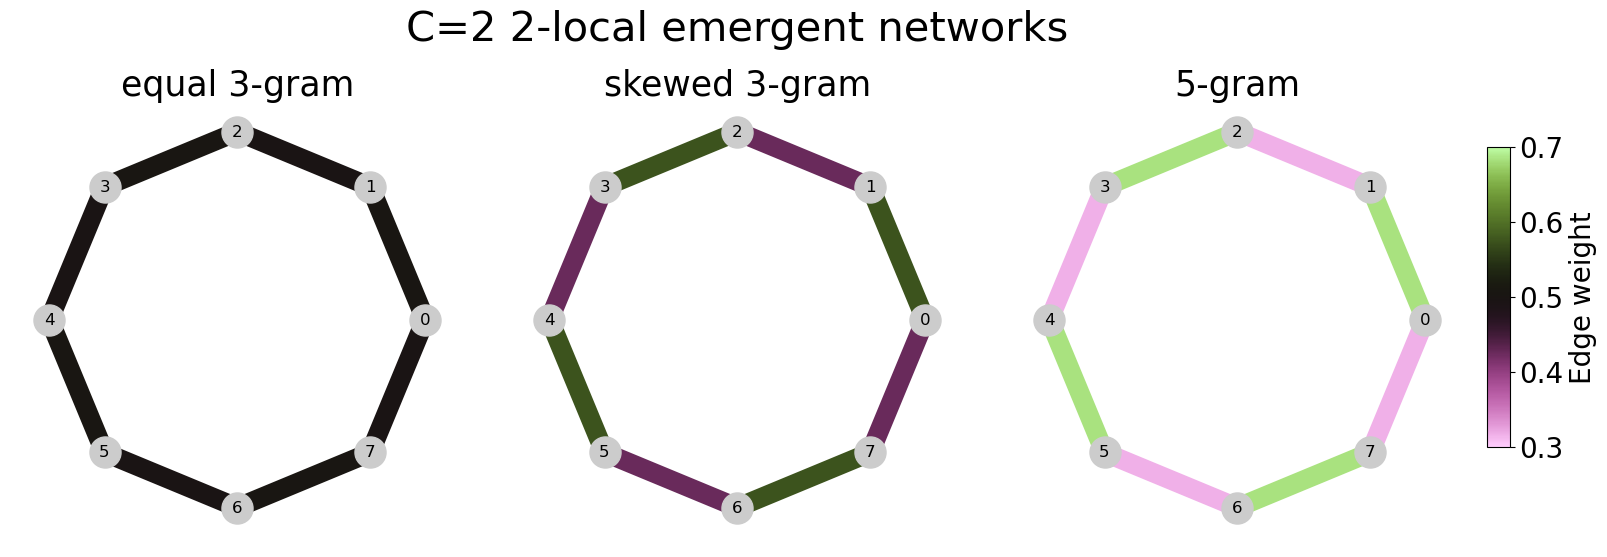

In [52]:
rule_names = ['1_3_0_3','1_3_1_3','ngram_5']

num_to_plot = len(rule_names)

fig, axs = plt.subplots(1,num_to_plot,figsize=(num_to_plot*5,5))

mappables = []
subplot_titles = ['equal 3-gram', 'skewed 3-gram','5-gram']
for i, rule_name in enumerate(rule_names):
    j_prob = np.mean(NM_gate_probs_all[rule_name][:,0])
    g_prob = 1-j_prob
    print(j_prob,g_prob)
    adj_mat = adj_matrix_c2_2local_gate_probs([j_prob,g_prob],8)

    axs[i].set_aspect('equal')

    cm = emergent_network_plot(adj_matrix=adj_mat, ax=axs[i], title=subplot_titles[i],
                        cmap=mpl.colormaps['vanimo'])
    mappables.append(cm)
    
divider = make_axes_locatable(axs[-1])
cax = fig.add_axes([1.0, 0.20, 0.015, 0.6])

fig.suptitle('C=2 2-local emergent networks',fontsize=30,y=1.075)

cbar = fig.colorbar(mappables[1], cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=20)
cbar.set_label(label='Edge weight',size=20)
plt.tight_layout(pad=0.0)

# Check order list with unitary evol.

Unnati brings up a great point -- this checking isn't a check. 

Consider a 4-qubit system, with qubits labelled 0,1,2,3

In our method of checking, we take, for example, $\rho_{(0,3)} (t)= Tr_{1,2}[\rho_{(0,1,2,3)} (t)]$ from get_2_qbit_dms(). 

Evolving with $U \rho_{(0,3)} (t) U^\dagger$ only equals $\rho_{(0,3)} (t+1) = Tr_{1,2}[\rho_{(0,1,2,3)} (t+1)]$ if $\rho_{(0,1,2,3)} (t+1) = \rho_{(0,3)} (t+1) \otimes \rho_{(1,2)}$, which clearly isn't always the case, as we can't always just write a 4-qubit density matrix as tensor product of two 2-qubit density matrices.

In [84]:
def unitary_op(denom=15.0):
    U = [[1.,0.,0.,0.],
        [0, np.cos(np.pi/denom), -np.sin(np.pi/denom), 0],
        [0, np.sin(np.pi/denom), np.cos(np.pi/denom), 0],
        [0,0,0,1]]
    return np.asarray(U)

def evolve_2qdms(U, rho):
    return U @ np.asarray(rho) @ U.T# / 4.0

In [85]:
def check_twoQdms_evolution(twoQdms, orders_list, trial_num, time_step): 
    pair_to_check = tuple([int(x) for x in orders_list[time_step-1][0]])
    # pair_to_check = (0,1)
    # pair_to_check = (0,7)
    # print(f'checking pair: {pair_to_check}')

    rho_t1_orig = twoQdms[trial_num][time_step-1][pair_to_check]._data.toarray().real
    rho_t2_orig = twoQdms[trial_num][time_step][pair_to_check]._data.toarray().real

    U = unitary_op()
    rho_t1_calc = np.asarray(twoQdms[trial_num][time_step-1][pair_to_check]._data.toarray().real)
    rho_t2_calc = evolve_2qdms(U,rho_t1_calc)

    diff = rho_t2_calc - rho_t2_orig

    # print(diff)

    # print(rho_t2_orig)
    # print(rho_t2_calc)

    # return (np.abs(diff) <= 1.0e-7).all() 
    return np.max(np.abs(diff))

In [82]:
# check for random
twoQdms_random = twoQdms_all['random']

for trial_num in range(0, 100): 
    matching = True
    time_step = 11
    while matching and time_step <= 50:
        matching = check_twoQdms_evolution(twoQdms_random, random_orders_list, trial_num, time_step)
        time_step += 1
    if time_step - 11 >= 10:
        print(trial_num)

NameError: name 'twoQdms_all' is not defined

In [ ]:
# check for NM rule
rule_name = '1_3_0_3'
twoQdms_NM = twoQdms_all[rule_name]

trial_num = 20
n_qubits = 8

pattern_dict = {
                'g': [(i, i + 1) for i in range(0, n_qubits - 1, 2)],
                'j': [(0, n_qubits - 1)] + [(i, i + 1) for i in range(1, n_qubits - 2, 2)]
            }

NM_order_list = list(NM_list_1_3_0_3[trial_num])
NM_order_list = [pattern_dict[gate] for gate in NM_order_list]

results = [] 
for t in range(11,400):
    res = check_twoQdms_evolution(twoQdms_NM, NM_order_list, trial_num, time_step=t)
    if res >= 1e-8:
        results.append((t,res))

In [54]:
# check for brickwork
rule_name = 'brick'
twoQdms_NM = get_2_qbit_dms(newdata_all[rule_name],n_qubits,"c2_2local", "NonMarkovian")

trial_num = 0
n_qubits = 8

pattern_dict = {
                'g': [(i, i + 1) for i in range(0, n_qubits - 1, 2)],
                'j': [(0, n_qubits - 1)] + [(i, i + 1) for i in range(1, n_qubits - 2, 2)]
            }

NM_order_list = list(NM_list_brick[trial_num])
NM_order_list = [pattern_dict[gate] for gate in NM_order_list]

results = [] 
for t in range(12,499):
    res = check_twoQdms_evolution(twoQdms_NM, NM_order_list, trial_num, time_step=t)
    if res >= 1e-8:
        results.append((t,res))

len(results)

NameError: name 'get_2_qbit_dms' is not defined

In [86]:
# check for deterministic
rule_name = 'g_j_j_j'
twoQdms_NM = get_2_qbit_dms(newdata_det[rule_name],n_qubits,"c2_2local", "NonMarkovian")

trial_num = 0
n_qubits = 8

pattern_dict = {
                'g': [(i, i + 1) for i in range(0, n_qubits - 1, 2)],
                'j': [(0, n_qubits - 1)] + [(i, i + 1) for i in range(1, n_qubits - 2, 2)]
            }

NM_order_list = list(NM_list_g_j_j_j[trial_num])
NM_order_list = [pattern_dict[gate] for gate in NM_order_list]

results = [] 
for t in range(12,499):
    res = check_twoQdms_evolution(twoQdms_NM, NM_order_list, trial_num, time_step=t)
    if res >= 1e-5:
        results.append((t,res))

len(results)

0

# Histograms grid

In [ ]:
%%script echo skipping
# datasets = [
#     full_sim_tz(pops_random_c4_th, 15),
#     full_sim_tz(pops_greedy_c4_th, 15),
#     full_sim_tz(pops_landmax_c4_th, 15),
#     full_sim_tz(pops_strongmax_c4_th, 15),
#     full_sim_tz(pops_mimic_c4_th, 15),
#     full_sim_tz(pops_random_c4_v1, 15),
#     full_sim_tz(pops_greedy_c4_v1, 15),
#     full_sim_tz(pops_landmax_c4_v1, 15),
#     full_sim_tz(pops_strongmax_c4_v1, 15),
#     full_sim_tz(pops_mimic_c4_v1, 15),
#     full_sim_tz(pops_random_c4_v2, 15),
#     full_sim_tz(pops_greedy_c4_v2, 15),
#     full_sim_tz(pops_landmax_c4_v2, 15),
#     full_sim_tz(pops_strongmax_c4_v2, 15),
#     full_sim_tz(pops_mimic_c4_v2, 15),
#     full_sim_tz(pops_random_c4_pure, 15),
#     full_sim_tz(pops_greedy_c4_pure, 15),
#     full_sim_tz(pops_landmax_c4_pure, 15),
#     full_sim_tz(pops_strongmax_c4_pure, 15),
#     full_sim_tz(pops_mimic_c4_pure, 15)
# ]

def plot_histograms_grid(datasets, time_range=(300, 499), figsize=(30, 24)):
    """
    Plot histograms with fit curves for multiple datasets in a grid layout.

    Parameters:
    -----------
    datasets : list
        List of datasets, each with shape (n_trials, n_timesteps, n_dimensions)
    time_range : tuple
        Range of time steps to include (start, end)
    figsize : tuple
        Figure size for the plot
    """
    n_datasets = len(datasets)
    start_time, end_time = time_range

    # Define grid layout
    n_rows = 4
    n_cols = 5

    if n_datasets > n_rows * n_cols:
        raise ValueError(f"Can only display {n_rows * n_cols} datasets in the grid, but got {n_datasets}")

    # Define colors for each column
    colors = ['#4169E1', '#DC143C', '#228B22', '#FF8C00', '#8A2BE2']

    # Define markers for each row
    markers = ['o', 'D', '^', 's']  # circle, diamond, triangle, square

    #pick your own
    threshold = 0.04322
    # Create figure with grid of subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()  # Flatten to make indexing easier

    # Find the min and max x values for each row to make x-axes uniform per row
    row_min_x = [float('inf')] * n_rows
    row_max_x = [float('-inf')] * n_rows

    # First pass: find min and max x values for each row
    for i, data in enumerate(datasets):
        if i >= n_rows * n_cols:
            continue

        row_idx = i // n_cols

        # Extract data for the specified time range
        time_slice = slice(start_time, end_time + 1)
        selected_data = data[:, time_slice, :]

        # Flatten the data for histogram
        flat_data = selected_data.reshape(-1)

        # Update min and max for the row
        row_min_x[row_idx] = min(row_min_x[row_idx], np.min(flat_data))
        row_max_x[row_idx] = max(row_max_x[row_idx], np.max(flat_data))
    # Process each dataset
    #DEFINE THESE VALUES!!!!!!
    max_density=[max_th,max_v1,max_v2,max_p]
    for i, data in enumerate(datasets):
        if i >= n_datasets:
            break

        n_trials, n_timesteps, n_dimensions = data.shape

        if n_dimensions != 12:
            raise ValueError(f"Dataset {i+1}: Expected 12 dimensions, but got {n_dimensions}")

        # Extract data for the specified time range
        time_slice = slice(start_time, end_time + 1)
        selected_data = data[:, time_slice, :]

        # Flatten the data for histogram
        flat_data = selected_data.reshape(-1)

        # Get the current subplot
        ax = axes[i]

        # Determine column index for color and row index for marker
        col_idx = i % n_cols
        row_idx = i // n_cols
        hist_color = colors[col_idx]

        # Create legend label based on row (CS1, CS2, CS3, CSP)
        if row_idx == 3:
            legend_label = f'CSP'
        else:
            legend_label = f'CS{row_idx+1}'

        # Create histogram with normalized y-axis (0-100)
        hist_values, bin_edges, patches = ax.hist(flat_data, bins=50, density=True,
                                          alpha=0.4, color=hist_color,
                                          label=legend_label)

        # Scale the y-axis values to range from 0 to 100
       # max_density = np.max([np.float64(48.98734484454637), np.float64(99.47113439635753), np.float64(73.97348246976217), np.float64(85.57198150664834), np.float64(111.69010767074764), np.float64(46.33570305988926), np.float64(48.9320488885684), np.float64(43.50713108942431), np.float64(35.64586632164801), np.float64(56.48715115034697), np.float64(46.30078458090764), np.float64(32.83104206837531), np.float64(32.73852054189013), np.float64(34.0456856172911), np.float64(52.345517352909724), np.float64(14.307420373054745), np.float64(25.980772528956667), np.float64(15.575665982851712), np.float64(18.41183738390349), np.float64(18.624787264412724)])
        #max_hist.append(max_density)
        #if max_density > 0:  # Avoid division by zero
            #for rect, height in zip(patches, hist_values):
                #rect.set_height(height / max_density * 100)

        # Set y-axis limits to 0-100 for all plots
        #if i in range(0,5):
        #    ax.set_ylim(0, max_th+5)
        #if i in range(5,10):
        #    ax.set_ylim(0, max_v1+5)
        #if i in range(10,15):
        #    ax.set_ylim(0, max_v2+5)
        #if i in range(15,20):
        #    ax.set_ylim(0, max_p+5)

        # Set uniform x-axis for all plots in this row
        #ax.set_xlim(row_min_x[row_idx], row_max_x[row_idx])

        # Calculate bin centers for curve fitting
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Fit normal distribution
        mu, sigma = stats.norm.fit(flat_data)
        kurtosis = stats.kurtosis(flat_data)  # This calculates the excess kurtosis
        skew = stats.skew(flat_data)  # This calculates the excess kurtosis
        actual_kurtosis = stats.kurtosis(flat_data) + 3
        prob_above_threshold = np.mean(np.abs(flat_data) > threshold)
        print(sigma)

        # Plot the fit curve
        x = np.linspace(row_min_x[row_idx], row_max_x[row_idx], 100)
        y = stats.norm.pdf(x, mu, sigma)

        # Scale the y values of the normal curve to the 0-100 range


        ax.plot(x, y, 'r-', linewidth=2, label=f'μ={mu:.3f}, σ={sigma:.3f}')

        # Add a point with the appropriate marker for the legend
        # This is a dummy point just for the marker in the legend
        ax.scatter([], [], color=hist_color, marker=markers[row_idx], s=100, label='_nolegend_')

        # Calculate additional statistics
        median = np.median(flat_data)
        min_val = np.min(flat_data)
        max_val = np.max(flat_data)
        p25 = np.percentile(flat_data, 25)
        p75 = np.percentile(flat_data, 75)

        # Add text box with statistics - fixed the LaTeX formatting
        stats_text = (f"Mean: {mu:.3f}\n"
                      f"Std Dev: {sigma:.3f}\n"
                      f"Kurtosis: {kurtosis:.3f}\n"
                      f"Skew: {skew:.3f}\n"
                      f"P($\\tau_{{z;NCP}}$): {prob_above_threshold:.3f}")

        # Add stats text box
        ax.text(0.95, 0.95, stats_text,
                transform=ax.transAxes,
                fontsize=18,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.2))

        # Add vertical lines for mean and median
        ax.axvline(x=mu, color='red', linestyle='--', alpha=0.6)
        ax.axvline(x=0.04322, color='black', linestyle='--', alpha=1)

        # Set titles and labels
        if i<5:
            # TODO: if needed later ax.set_title(f'R{i+1}', fontsize=28)
            ax.set_title(f'NM R0022', fontsize=28)

        # Only add x-axis label to bottom row
        if i >= n_datasets - n_cols:
            ax.set_xlabel(r'$\tau_z$', fontsize=28)

        # Only add y-axis label to leftmost column
        if i % n_cols == 0:
            ax.set_ylabel('Density (%)', fontsize=25)

        # Create custom legend with marker and label
        handles, labels = ax.get_legend_handles_labels()
        # Only keep the first handle (histogram) and its label
        legend_handle = handles[0]
        # Modify the legend handle to use the appropriate marker
        custom_handle = mpl.lines.Line2D([0], [0], marker=markers[row_idx], color=hist_color,
                             markersize=10, linestyle='None')

        ax.legend(handles=[custom_handle, handles[1]],
                  labels=[legend_label, labels[1]],
                  loc='upper left', fontsize=15)

        # Add grid
        ax.grid(True, linestyle='--', alpha=0.5)

    # Hide any unused subplots
    for j in range(n_datasets, n_rows * n_cols):
        axes[j].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout
    print(max_density)
    return fig

# Assuming your dataset is a list of 20 numpy arrays, each with shape (100, 500, 12)
fig = plot_histograms_grid(datasets)
plt.savefig('tz_histogram_per_rule_per_IC_ens_avg_c4.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'datasets' is not defined